In [ ]:
# ============================================================
# DATASET AND EXPERIMENTAL SETUP
# EXACT WORKING VERSION FOR GOOGLE COLAB
# Oxford-IIIT Pet Dataset
# ============================================================

import os
import random
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow import keras


# ------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 37
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TensorFlow Version:", tf.__version__)


# ------------------------------------------------------------
# 2. DOWNLOAD DATASET TO FIXED FOLDERS
# ------------------------------------------------------------

DATA_DIR = Path("/content/oxford_iiit_pet")
DATA_DIR.mkdir(parents=True, exist_ok=True)

IMAGES_ARCHIVE = DATA_DIR / "images.tar.gz"
ANNOTATIONS_ARCHIVE = DATA_DIR / "annotations.tar.gz"

IMAGES_URL = (
    "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
)

ANNOTATIONS_URL = (
    "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"
)


# Download only if files do not already exist
if not IMAGES_ARCHIVE.exists():
    print("Downloading images...")
    urllib.request.urlretrieve(
        IMAGES_URL,
        IMAGES_ARCHIVE
    )

if not ANNOTATIONS_ARCHIVE.exists():
    print("Downloading annotations...")
    urllib.request.urlretrieve(
        ANNOTATIONS_URL,
        ANNOTATIONS_ARCHIVE
    )


# ------------------------------------------------------------
# 3. EXTRACT IMAGES AND ANNOTATIONS
# ------------------------------------------------------------

IMAGES_DIR = DATA_DIR / "images"
ANNOTATIONS_DIR = DATA_DIR / "annotations"

if not IMAGES_DIR.exists():
    print("Extracting images...")

    with tarfile.open(
        IMAGES_ARCHIVE,
        "r:gz"
    ) as tar:
        tar.extractall(
            path=DATA_DIR
        )


if not ANNOTATIONS_DIR.exists():
    print("Extracting annotations...")

    with tarfile.open(
        ANNOTATIONS_ARCHIVE,
        "r:gz"
    ) as tar:
        tar.extractall(
            path=DATA_DIR
        )


# ------------------------------------------------------------
# 4. VERIFY REQUIRED FILES
# ------------------------------------------------------------

TRAINVAL_FILE = ANNOTATIONS_DIR / "trainval.txt"
TEST_FILE = ANNOTATIONS_DIR / "test.txt"

print("\nDataset Paths:")
print("Images:", IMAGES_DIR)
print("Trainval:", TRAINVAL_FILE)
print("Test:", TEST_FILE)

assert IMAGES_DIR.exists(), "Images folder not found"
assert TRAINVAL_FILE.exists(), "trainval.txt not found"
assert TEST_FILE.exists(), "test.txt not found"


# ------------------------------------------------------------
# 5. READ ANNOTATION FILE
# ------------------------------------------------------------

def read_annotation_file(annotation_file):

    image_paths = []
    labels = []

    with open(annotation_file, "r") as file:

        for line in file:

            # Ignore comment lines
            if line.startswith("#"):
                continue

            parts = line.strip().split()

            if len(parts) < 2:
                continue

            image_name = parts[0]

            # Class ID: 1–37 -> convert to 0–36
            class_id = int(parts[1]) - 1

            image_path = (
                IMAGES_DIR / f"{image_name}.jpg"
            )

            # Add valid image
            if image_path.exists():

                image_paths.append(
                    str(image_path)
                )

                labels.append(
                    class_id
                )

    return image_paths, labels


# ------------------------------------------------------------
# 6. LOAD OFFICIAL DATA
# ------------------------------------------------------------

trainval_paths, trainval_labels = read_annotation_file(
    TRAINVAL_FILE
)

test_paths, test_labels = read_annotation_file(
    TEST_FILE
)


# ------------------------------------------------------------
# 7. VERIFY DATA WAS LOADED
# ------------------------------------------------------------

print("\nOfficial Train/Validation Images:", len(trainval_paths))
print("Official Test Images:", len(test_paths))

if len(trainval_paths) == 0 or len(test_paths) == 0:
    raise ValueError(
        "No images were loaded. "
        "Dataset extraction failed."
    )


# ------------------------------------------------------------
# 8. CREATE TRAIN / VALIDATION SPLIT
# ------------------------------------------------------------

trainval_paths = np.array(trainval_paths)
trainval_labels = np.array(trainval_labels)

# Shuffle official training data
indices = np.arange(len(trainval_paths))

np.random.shuffle(indices)

trainval_paths = trainval_paths[indices]
trainval_labels = trainval_labels[indices]


# 80% Training
# 20% Validation

split_index = int(
    0.80 * len(trainval_paths)
)

train_paths = trainval_paths[:split_index]
train_labels = trainval_labels[:split_index]

val_paths = trainval_paths[split_index:]
val_labels = trainval_labels[split_index:]

test_paths = np.array(test_paths)
test_labels = np.array(test_labels)


# ------------------------------------------------------------
# 9. DATASET SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("DATASET SPLIT")
print("=" * 55)

print("Training Samples  :", len(train_paths))
print("Validation Samples:", len(val_paths))
print("Test Samples      :", len(test_paths))
print("Number of Classes :", NUM_CLASSES)

print("=" * 55)


# ------------------------------------------------------------
# 10. IMAGE PREPROCESSING
# ------------------------------------------------------------

def preprocess_image(image_path, label):

    # Read image
    image = tf.io.read_file(
        image_path
    )

    # Decode as RGB
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Resize to 224 × 224
    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    # Convert to float32
    image = tf.cast(
        image,
        tf.float32
    )

    # MobileNetV2 normalization
    # [0, 255] -> [-1, 1]
    image = keras.applications.mobilenet_v2.preprocess_input(
        image
    )

    return image, label


# ------------------------------------------------------------
# 11. CREATE TRAINING DATASET
# ------------------------------------------------------------

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

train_ds = train_ds.shuffle(
    buffer_size=len(train_paths),
    seed=SEED
)

train_ds = train_ds.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.batch(
    BATCH_SIZE
)

train_ds = train_ds.prefetch(
    AUTOTUNE
)


# ------------------------------------------------------------
# 12. CREATE VALIDATION DATASET
# ------------------------------------------------------------

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_ds = val_ds.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.batch(
    BATCH_SIZE
)

val_ds = val_ds.prefetch(
    AUTOTUNE
)


# ------------------------------------------------------------
# 13. CREATE TEST DATASET
# ------------------------------------------------------------

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

test_ds = test_ds.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.batch(
    BATCH_SIZE
)

test_ds = test_ds.prefetch(
    AUTOTUNE
)


# ------------------------------------------------------------
# 14. VERIFY ONE BATCH
# ------------------------------------------------------------

for images, labels in train_ds.take(1):

    print("\nBATCH VERIFICATION")
    print("Image Batch Shape:", images.shape)
    print("Label Batch Shape:", labels.shape)

    print(
        "Pixel Value Range:",
        tf.reduce_min(images).numpy(),
        "to",
        tf.reduce_max(images).numpy()
    )


# ------------------------------------------------------------
# 15. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET AND EXPERIMENTAL SETUP COMPLETE")
print("=" * 60)

print("Dataset           : Oxford-IIIT Pet Dataset")
print("Image Type        : RGB")
print("Image Size        : 224 x 224 x 3")
print("Number of Classes : 37")
print("Training Samples  :", len(train_paths))
print("Validation Samples:", len(val_paths))
print("Test Samples      :", len(test_paths))
print("Base Model        : MobileNetV2")
print("Normalization     : MobileNetV2 preprocessing")
print("Test Set          : Kept untouched")

print("=" * 60)

TensorFlow Version: 2.20.0
Extracting images...


/tmp/ipykernel_917/1441371637.py:84: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(


Extracting annotations...


/tmp/ipykernel_917/1441371637.py:96: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(



Dataset Paths:
Images: /content/oxford_iiit_pet/images
Trainval: /content/oxford_iiit_pet/annotations/trainval.txt
Test: /content/oxford_iiit_pet/annotations/test.txt

Official Train/Validation Images: 3680
Official Test Images: 3669

DATASET SPLIT
Training Samples  : 2944
Validation Samples: 736
Test Samples      : 3669
Number of Classes : 37

BATCH VERIFICATION
Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32,)
Pixel Value Range: -1.0 to 1.0

DATASET AND EXPERIMENTAL SETUP COMPLETE
Dataset           : Oxford-IIIT Pet Dataset
Image Type        : RGB
Image Size        : 224 x 224 x 3
Number of Classes : 37
Training Samples  : 2944
Validation Samples: 736
Test Samples      : 3669
Base Model        : MobileNetV2
Normalization     : MobileNetV2 preprocessing
Test Set          : Kept untouched


In [ ]:
# ============================================================
# TASK 2: MOBILENETV2 ARCHITECTURE
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ------------------------------------------------------------
# 1. LOAD PRETRAINED MOBILENETV2
# ------------------------------------------------------------

base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)


# ------------------------------------------------------------
# 2. FREEZE THE PRETRAINED BASE MODEL
# ------------------------------------------------------------

base_model.trainable = False


# ------------------------------------------------------------
# 3. BUILD THE CLASSIFICATION MODEL
# ------------------------------------------------------------

inputs = keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="input_image"
)


# MobileNetV2 feature extraction
x = base_model(
    inputs,
    training=False
)


# Global Average Pooling
x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)


# Dropout for regularization
x = layers.Dropout(
    0.2,
    name="dropout"
)(x)


# Output layer for 37 pet breeds
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classification_output"
)(x)


# ------------------------------------------------------------
# 4. CREATE FINAL MODEL
# ------------------------------------------------------------

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="MobileNetV2_Pet_Classifier"
)


# ------------------------------------------------------------
# 5. DISPLAY MODEL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MOBILENETV2 PET CLASSIFICATION MODEL")
print("=" * 70)

model.summary()


# ------------------------------------------------------------
# 6. DISPLAY ARCHITECTURE INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SIMPLIFIED MOBILENETV2 ARCHITECTURE")
print("=" * 70)

print("""
Input Image
224 x 224 x 3
        |
        v
Initial Convolution
        |
        v
Depthwise Convolution
        |
        v
Pointwise 1 x 1 Convolution
        |
        v
Inverted Residual Blocks
        |
        v
Linear Bottlenecks
        |
        v
MobileNetV2 Feature Maps
        |
        v
Global Average Pooling
        |
        v
Dropout
        |
        v
Dense Layer (37 Classes)
        |
        v
Softmax Output
""")


# ------------------------------------------------------------
# 7. MOBILENETV2 COMPONENTS
# ------------------------------------------------------------

print("=" * 70)
print("IMPORTANT MOBILENETV2 COMPONENTS")
print("=" * 70)

print("1. Depthwise Convolution")
print("   Performs spatial convolution separately for each channel.")

print("\n2. Pointwise 1 x 1 Convolution")
print("   Combines information across different feature channels.")

print("\n3. Inverted Residual Blocks")
print("   Expand -> depthwise convolution -> project.")

print("\n4. Linear Bottlenecks")
print("   Preserve important information in low-dimensional layers.")

print("\n5. Batch Normalization")
print("   Stabilizes and accelerates model training.")

print("\n6. ReLU6 Activation")
print("   Uses the activation function: min(max(0, x), 6).")

print("=" * 70)


# ------------------------------------------------------------
# 8. DISPLAY BASE MODEL INFORMATION
# ------------------------------------------------------------

print("\nMODEL CONFIGURATION")
print("-" * 70)

print("Input Shape          :", (IMG_SIZE, IMG_SIZE, 3))
print("Base Architecture    : MobileNetV2")
print("Pretrained Weights   : ImageNet")
print("Base Model           : Frozen")
print("Global Pooling       : GlobalAveragePooling2D")
print("Dropout Rate         : 0.2")
print("Output Classes       :", NUM_CLASSES)
print("Output Activation    : Softmax")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

MOBILENETV2 PET CLASSIFICATION MODEL


Model: "MobileNetV2_Pet_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_output (Dense)   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


SIMPLIFIED MOBILENETV2 ARCHITECTURE

Input Image
224 x 224 x 3
        |
        v
Initial Convolution
        |
        v
Depthwise Convolution
        |
        v
Pointwise 1 x 1 Convolution
        |
        v
Inverted Residual Blocks
        |
        v
Linear Bottlenecks
        |
        v
MobileNetV2 Feature Maps
        |
        v
Global Average Pooling
        |
        v
Dropout
        |
        v
Dense Layer (37 Classes)
        |
        v
Softmax Output

IMPORTANT MOBILENETV2 COMPONENTS
1. Depthwise Convolution
   Performs spatial convolution separately for each channel.

2. Pointwise 1 x 1 Convolution
   Combines information across different feature channels.

3. Inverted Residual Blocks
   Expand -> depthwise convolution -> project.

4. Linear Bottlenecks
   Preserve important information in low-dimensional layers.

5. Batch Normalization
   Stabilizes and accelerates model training.

6. ReLU6 Activation
   Uses the activation function: min(max(0, x), 6).

MODEL CONFI


TRAINING WITH: Zero Initialization
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 36s 196ms/step - accuracy: 0.7643 - loss: 1.1597 - val_accuracy: 0.9158 - val_loss: 0.4161
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9443 - loss: 0.2899 - val_accuracy: 0.9171 - val_loss: 0.3134
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.9677 - loss: 0.1835 - val_accuracy: 0.9212 - val_loss: 0.2707
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.9786 - loss: 0.1318 - val_accuracy: 0.9226 - val_loss: 0.2663
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9878 - loss: 0.0971 - val_accuracy: 0.9239 - val_loss: 0.2437
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.9966 - loss: 0.0732 - val_accuracy: 0.9280 - val_loss: 0.2505
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9980 - loss: 0.0581 - val_accuracy: 0.9198 - val_loss: 0.2413
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.999

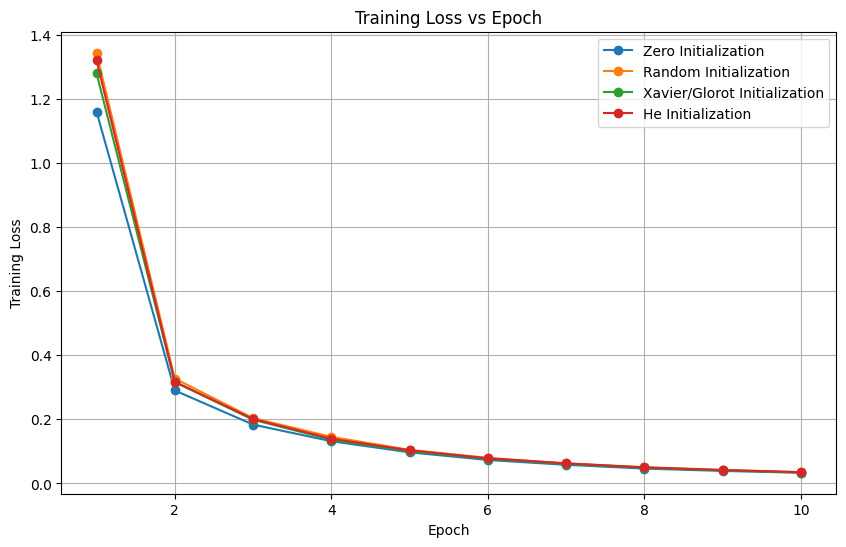

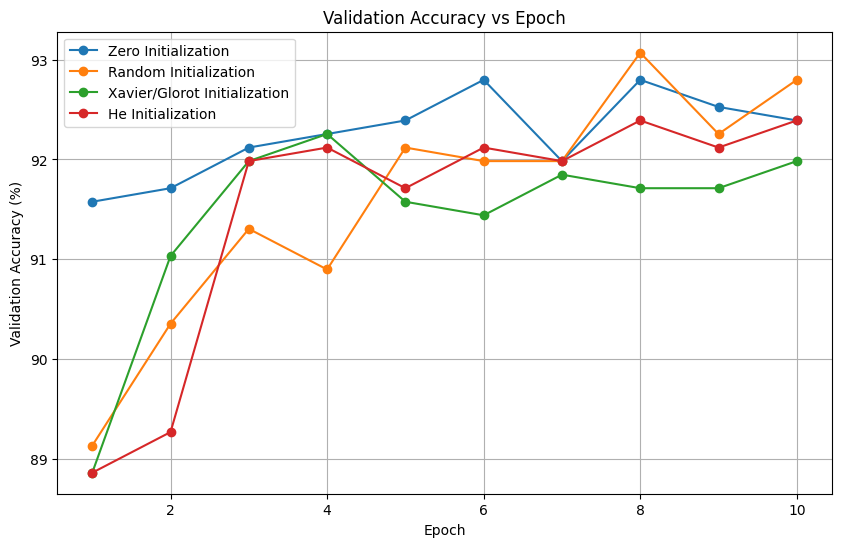


FINAL INITIALIZATION COMPARISON

Zero Initialization
Final Training Loss: 0.0334
Final Validation Accuracy: 92.39 %
Best Validation Accuracy: 92.8 %

Random Initialization
Final Training Loss: 0.0352
Final Validation Accuracy: 92.8 %
Best Validation Accuracy: 93.07 %

Xavier/Glorot Initialization
Final Training Loss: 0.0339
Final Validation Accuracy: 91.98 %
Best Validation Accuracy: 92.26 %

He Initialization
Final Training Loss: 0.0351
Final Validation Accuracy: 92.39 %
Best Validation Accuracy: 92.39 %

BEST INITIALIZATION METHOD: Random Initialization
BEST VALIDATION ACCURACY: 93.07 %


In [ ]:
# ============================================================
# TASK 3: WEIGHT INITIALIZATION COMPARISON
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers, initializers


# ------------------------------------------------------------
# 1. EXPERIMENT SETTINGS
# ------------------------------------------------------------

EPOCHS = 10
LEARNING_RATE = 0.001

initialization_methods = {

    "Zero Initialization": initializers.Zeros(),

    "Random Initialization": initializers.RandomNormal(
        mean=0.0,
        stddev=0.05
    ),

    "Xavier/Glorot Initialization": initializers.GlorotUniform(
        seed=SEED
    ),

    "He Initialization": initializers.HeNormal(
        seed=SEED
    )
}


# ------------------------------------------------------------
# 2. FUNCTION TO CREATE A MODEL
# ------------------------------------------------------------

def create_model(kernel_initializer):

    # Use the same pretrained MobileNetV2 base
    # for each experiment

    base = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained MobileNetV2 layers
    base.trainable = False


    # Input layer
    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    )


    # MobileNetV2 feature extraction
    x = base(
        inputs,
        training=False
    )


    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)


    # --------------------------------------------------------
    # CLASSIFICATION LAYER WITH SELECTED INITIALIZATION
    # --------------------------------------------------------

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_initializer=kernel_initializer,
        bias_initializer="zeros"
    )(x)


    # Create model
    model = keras.Model(
        inputs,
        outputs
    )


    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )


    return model


# ------------------------------------------------------------
# 3. TRAIN EACH INITIALIZATION STRATEGY
# ------------------------------------------------------------

histories = {}

for name, initializer in initialization_methods.items():

    print("\n" + "=" * 70)
    print("TRAINING WITH:", name)
    print("=" * 70)


    # Clear previous model from memory
    keras.backend.clear_session()


    # Create new model
    model_init = create_model(
        initializer
    )


    # Train model
    history = model_init.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )


    # Store training history
    histories[name] = history.history


print("\nALL INITIALIZATION EXPERIMENTS COMPLETED!")
# ============================================================
# PLOT 1: TRAINING LOSS VS EPOCH
# ============================================================

plt.figure(figsize=(10, 6))

for name, history in histories.items():

    plt.plot(
        range(1, EPOCHS + 1),
        history["loss"],
        marker="o",
        label=name
    )


plt.title("Training Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.legend()

plt.grid(True)

plt.show()
# ============================================================
# PLOT 2: VALIDATION ACCURACY VS EPOCH
# ============================================================

plt.figure(figsize=(10, 6))

for name, history in histories.items():

    validation_accuracy = (
        np.array(history["val_accuracy"]) * 100
    )


    plt.plot(
        range(1, EPOCHS + 1),
        validation_accuracy,
        marker="o",
        label=name
    )


plt.title("Validation Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()
# ============================================================
# FINAL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("FINAL INITIALIZATION COMPARISON")
print("=" * 70)

results = {}

for name, history in histories.items():

    final_train_loss = history["loss"][-1]

    final_val_accuracy = (
        history["val_accuracy"][-1] * 100
    )

    best_val_accuracy = (
        max(history["val_accuracy"]) * 100
    )

    results[name] = {
        "Final Training Loss": final_train_loss,
        "Final Validation Accuracy": final_val_accuracy,
        "Best Validation Accuracy": best_val_accuracy
    }


for name, result in results.items():

    print("\n" + name)

    print(
        "Final Training Loss:",
        round(
            result["Final Training Loss"],
            4
        )
    )

    print(
        "Final Validation Accuracy:",
        round(
            result["Final Validation Accuracy"],
            2
        ),
        "%"
    )

    print(
        "Best Validation Accuracy:",
        round(
            result["Best Validation Accuracy"],
            2
        ),
        "%"
    )


# Find the initialization method with
# the highest validation accuracy

best_method = max(
    results,
    key=lambda x: results[x]["Best Validation Accuracy"]
)


print("\n" + "=" * 70)
print("BEST INITIALIZATION METHOD:", best_method)
print(
    "BEST VALIDATION ACCURACY:",
    round(
        results[best_method]["Best Validation Accuracy"],
        2
    ),
    "%"
)
print("=" * 70)


TRAINING: No Regularization
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - accuracy: 0.6967 - loss: 1.2765 - val_accuracy: 0.8927 - val_loss: 0.4595
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9256 - loss: 0.3191 - val_accuracy: 0.9103 - val_loss: 0.3428
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.9579 - loss: 0.1997 - val_accuracy: 0.9130 - val_loss: 0.3006
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9766 - loss: 0.1401 - val_accuracy: 0.9117 - val_loss: 0.2833
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.9885 - loss: 0.1008 - val_accuracy: 0.9144 - val_loss: 0.2773
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9935 - loss: 0.0777 - val_accuracy: 0.9158 - val_loss: 0.2755
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9963 - loss: 0.0619 - val_accuracy: 0.9158 - val_loss: 0.2599
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9983 - loss:

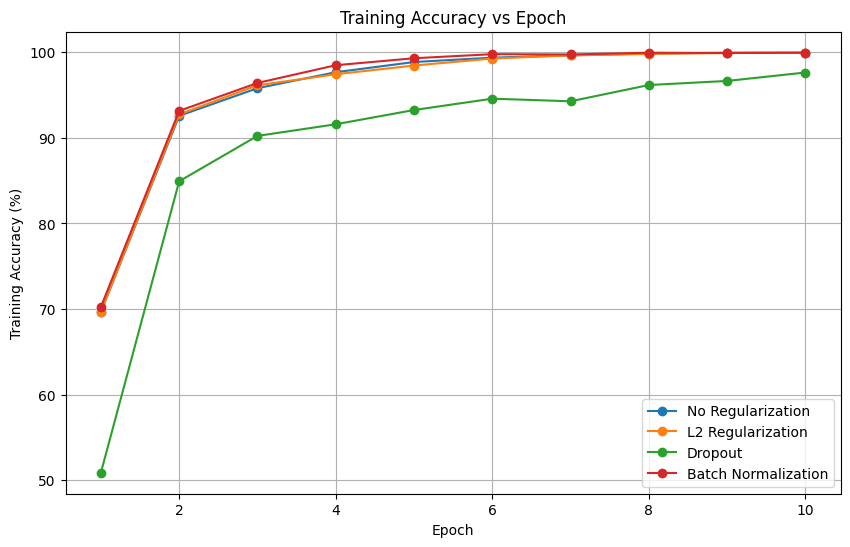

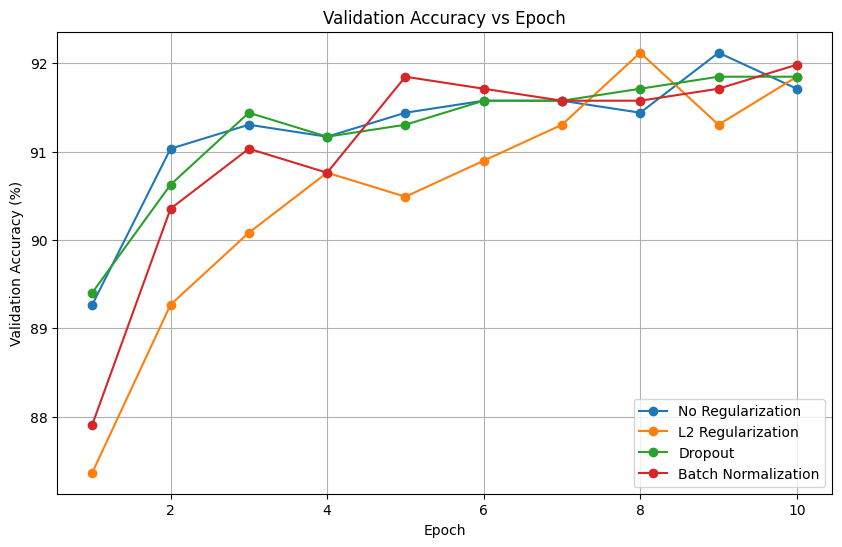

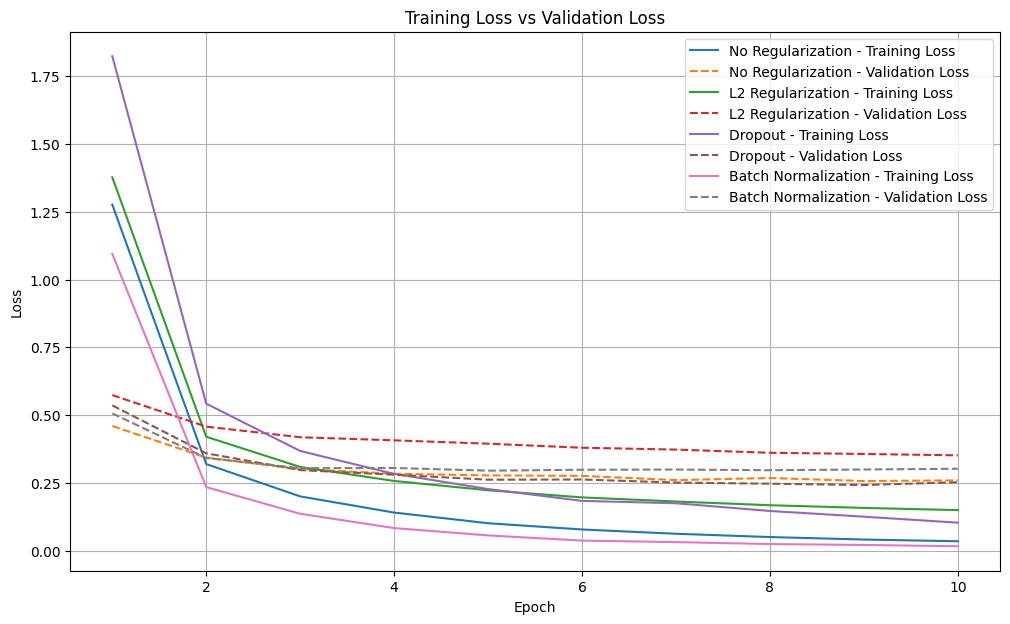


REGULARIZATION EXPERIMENT RESULTS

No Regularization
Final Training Accuracy: 99.93 %
Final Validation Accuracy: 91.71 %
Best Validation Accuracy: 92.12 %
Overfitting Gap: 8.22 %

L2 Regularization
Final Training Accuracy: 99.93 %
Final Validation Accuracy: 91.85 %
Best Validation Accuracy: 92.12 %
Overfitting Gap: 8.08 %

Dropout
Final Training Accuracy: 97.62 %
Final Validation Accuracy: 91.85 %
Best Validation Accuracy: 91.85 %
Overfitting Gap: 5.77 %

Batch Normalization
Final Training Accuracy: 99.93 %
Final Validation Accuracy: 91.98 %
Best Validation Accuracy: 91.98 %
Overfitting Gap: 7.95 %



In [ ]:
# ============================================================
# TASK 4: REGULARIZATION AND OVERFITTING COMPARISON
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers, regularizers


# ------------------------------------------------------------
# 1. EXPERIMENT SETTINGS
# ------------------------------------------------------------

EPOCHS = 10
LEARNING_RATE = 0.001

regularization_methods = [
    "No Regularization",
    "L2 Regularization",
    "Dropout",
    "Batch Normalization"
]


# ------------------------------------------------------------
# 2. CREATE MODEL FUNCTION
# ------------------------------------------------------------

def create_regularized_model(method):

    # Load pretrained MobileNetV2
    base = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained feature extractor
    base.trainable = False


    # Input layer
    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    )


    # Extract features
    x = base(
        inputs,
        training=False
    )


    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)


    # --------------------------------------------------------
    # APPLY SELECTED REGULARIZATION METHOD
    # --------------------------------------------------------

    if method == "L2 Regularization":

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax",
            kernel_regularizer=regularizers.l2(0.001)
        )(x)


    elif method == "Dropout":

        x = layers.Dropout(
            0.5
        )(x)

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )(x)


    elif method == "Batch Normalization":

        x = layers.BatchNormalization()(x)

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )(x)


    else:
        # No Regularization

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )(x)


    # Create model
    model = keras.Model(
        inputs,
        outputs
    )


    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )


    return model


# ------------------------------------------------------------
# 3. TRAIN ALL MODELS
# ------------------------------------------------------------

regularization_histories = {}


for method in regularization_methods:

    print("\n" + "=" * 70)
    print("TRAINING:", method)
    print("=" * 70)


    # Clear previous model from memory
    keras.backend.clear_session()


    # Create model
    model_regularization = (
        create_regularized_model(method)
    )


    # Train
    history = model_regularization.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )


    # Store history
    regularization_histories[method] = (
        history.history
    )


print("\n" + "=" * 70)
print("ALL REGULARIZATION EXPERIMENTS COMPLETED")
print("=" * 70)

# ============================================================
# PLOT 1: TRAINING ACCURACY VS EPOCH
# ============================================================

plt.figure(figsize=(10, 6))


for method, history in regularization_histories.items():

    plt.plot(
        range(1, EPOCHS + 1),
        np.array(history["accuracy"]) * 100,
        marker="o",
        label=method
    )


plt.title("Training Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Training Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# PLOT 2: VALIDATION ACCURACY VS EPOCH
# ============================================================

plt.figure(figsize=(10, 6))


for method, history in regularization_histories.items():

    plt.plot(
        range(1, EPOCHS + 1),
        np.array(history["val_accuracy"]) * 100,
        marker="o",
        label=method
    )


plt.title("Validation Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()
# ============================================================
# PLOT 3: TRAINING LOSS AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(12, 7))


for method, history in regularization_histories.items():

    plt.plot(
        range(1, EPOCHS + 1),
        history["loss"],
        label=method + " - Training Loss"
    )


    plt.plot(
        range(1, EPOCHS + 1),
        history["val_loss"],
        linestyle="--",
        label=method + " - Validation Loss"
    )


plt.title("Training Loss vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# FINAL REGULARIZATION COMPARISON
# ============================================================

print("\n" + "=" * 80)
print("REGULARIZATION EXPERIMENT RESULTS")
print("=" * 80)


results = {}


for method, history in regularization_histories.items():

    final_train_accuracy = (
        history["accuracy"][-1] * 100
    )

    final_val_accuracy = (
        history["val_accuracy"][-1] * 100
    )

    best_val_accuracy = (
        max(history["val_accuracy"]) * 100
    )

    overfitting_gap = (
        final_train_accuracy
        -
        final_val_accuracy
    )


    results[method] = {

        "Final Training Accuracy":
            final_train_accuracy,

        "Final Validation Accuracy":
            final_val_accuracy,

        "Best Validation Accuracy":
            best_val_accuracy,

        "Overfitting Gap":
            overfitting_gap
    }


for method, result in results.items():

    print("\n" + method)

    print(
        "Final Training Accuracy:",
        round(
            result["Final Training Accuracy"],
            2
        ),
        "%"
    )

    print(
        "Final Validation Accuracy:",
        round(
            result["Final Validation Accuracy"],
            2
        ),
        "%"
    )

    print(
        "Best Validation Accuracy:",
        round(
            result["Best Validation Accuracy"],
            2
        ),
        "%"
    )

    print(
        "Overfitting Gap:",
        round(
            result["Overfitting Gap"],
            2
        ),
        "%"
    )


print("\n" + "=" * 80)


TRAINING WITH: Zero Initialization
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - accuracy: 0.7748 - loss: 1.1755 - val_accuracy: 0.8981 - val_loss: 0.4319
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.9399 - loss: 0.2925 - val_accuracy: 0.9171 - val_loss: 0.3204
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.9677 - loss: 0.1853 - val_accuracy: 0.9266 - val_loss: 0.2691
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.9806 - loss: 0.1289 - val_accuracy: 0.9130 - val_loss: 0.2571
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.9878 - loss: 0.0982 - val_accuracy: 0.9212 - val_loss: 0.2588
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9946 - loss: 0.0739 - val_accuracy: 0.9226 - val_loss: 0.2515
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9983 - loss: 0.0584 - val_accuracy: 0.9212 - val_loss: 0.2456
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.9

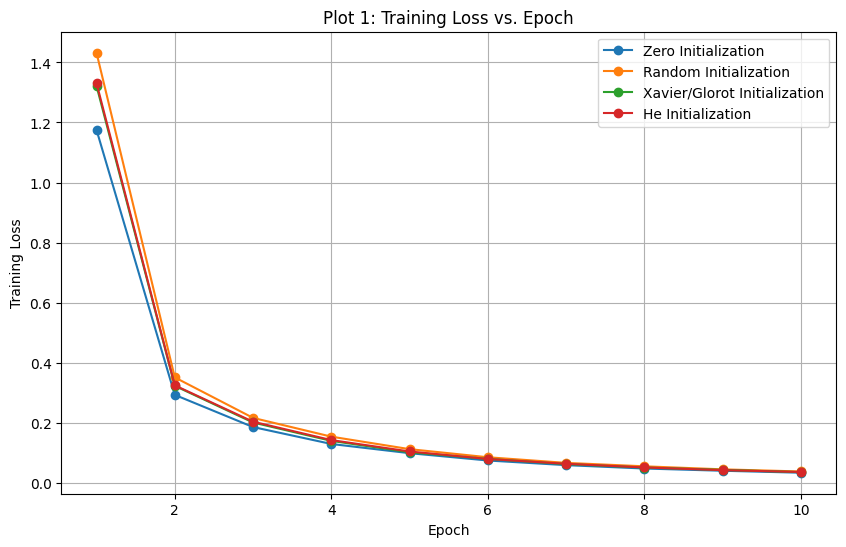

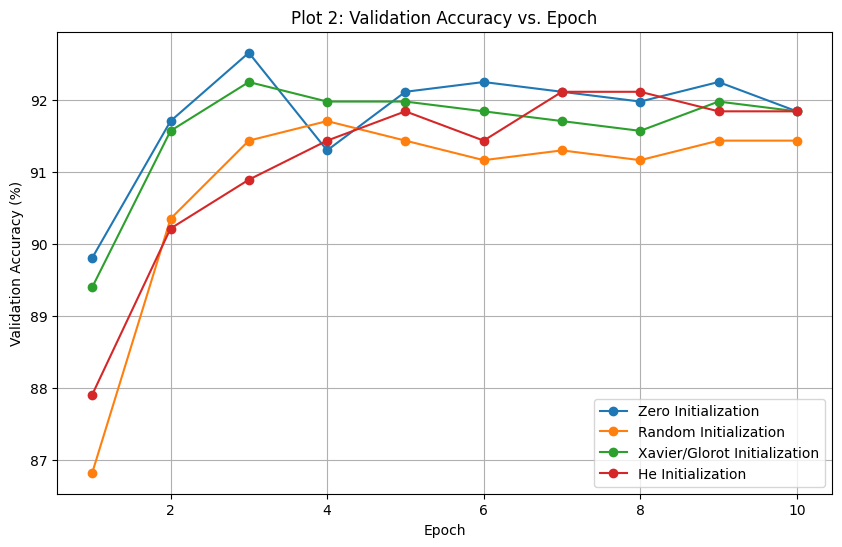


WEIGHT INITIALIZATION CONVERGENCE ANALYSIS

Method: Zero Initialization
Final Training Loss: 0.0331
Best Training Loss: 0.0331
Best Loss Reached at Epoch: 10
Final Validation Accuracy: 91.85 %
Best Validation Accuracy: 92.66 %

Method: Random Initialization
Final Training Loss: 0.0372
Best Training Loss: 0.0372
Best Loss Reached at Epoch: 10
Final Validation Accuracy: 91.44 %
Best Validation Accuracy: 91.71 %

Method: Xavier/Glorot Initialization
Final Training Loss: 0.0351
Best Training Loss: 0.0351
Best Loss Reached at Epoch: 10
Final Validation Accuracy: 91.85 %
Best Validation Accuracy: 92.26 %

Method: He Initialization
Final Training Loss: 0.0355
Best Training Loss: 0.0355
Best Loss Reached at Epoch: 10
Final Validation Accuracy: 91.85 %
Best Validation Accuracy: 92.12 %

FINAL RESULT
Best Initialization Method: Zero Initialization
Best Validation Accuracy: 92.66 %

Conclusion:
Zero Initialization showed the best validation performance in this experiment.
Use the Training Loss v

In [ ]:
# ============================================================
# 5. WEIGHT INITIALIZATION EXPERIMENT
# ============================================================
#
# Compare:
# 1. Zero Initialization
# 2. Random Initialization
# 3. Xavier / Glorot Initialization
# 4. He Initialization
#
# Plot 1: Training Loss vs. Epoch
# Plot 2: Validation Accuracy vs. Epoch
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers, initializers


# ------------------------------------------------------------
# 2. EXPERIMENT SETTINGS
# ------------------------------------------------------------

EPOCHS = 10
LEARNING_RATE = 0.001

# Set seed for reproducibility
SEED = 42

keras.utils.set_random_seed(SEED)


# ------------------------------------------------------------
# 3. INITIALIZATION METHODS
# ------------------------------------------------------------

initialization_methods = {

    "Zero Initialization":
        initializers.Zeros(),

    "Random Initialization":
        initializers.RandomNormal(
            mean=0.0,
            stddev=0.05,
            seed=SEED
        ),

    "Xavier/Glorot Initialization":
        initializers.GlorotUniform(
            seed=SEED
        ),

    "He Initialization":
        initializers.HeNormal(
            seed=SEED
        )
}


# ------------------------------------------------------------
# 4. FUNCTION TO CREATE MODEL
# ------------------------------------------------------------

def create_initialization_model(initializer):

    # Load pretrained MobileNetV2
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )


    # Freeze pretrained MobileNetV2 layers
    base_model.trainable = False


    # Input Layer
    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    )


    # Extract features using MobileNetV2
    x = base_model(
        inputs,
        training=False
    )


    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)


    # Classification Layer
    # The selected initialization method is applied here
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_initializer=initializer,
        bias_initializer="zeros"
    )(x)


    # Create model
    model = keras.Model(
        inputs=inputs,
        outputs=outputs
    )


    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )


    return model


# ============================================================
# 5. TRAIN MODELS WITH DIFFERENT INITIALIZATIONS
# ============================================================

histories = {}


for method_name, initializer in initialization_methods.items():

    print("\n" + "=" * 70)
    print("TRAINING WITH:", method_name)
    print("=" * 70)


    # Clear previous model from memory
    keras.backend.clear_session()


    # Set seed again for fair comparison
    keras.utils.set_random_seed(SEED)


    # Create model
    model = create_initialization_model(
        initializer
    )


    # Train model
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )


    # Save training history
    histories[method_name] = history.history


# ============================================================
# 6. PLOT 1:
# TRAINING LOSS VS. EPOCH
# ============================================================

plt.figure(figsize=(10, 6))


for method_name, history in histories.items():

    plt.plot(
        range(1, EPOCHS + 1),
        history["loss"],
        marker="o",
        label=method_name
    )


plt.title("Plot 1: Training Loss vs. Epoch")

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 7. PLOT 2:
# VALIDATION ACCURACY VS. EPOCH
# ============================================================

plt.figure(figsize=(10, 6))


for method_name, history in histories.items():

    plt.plot(
        range(1, EPOCHS + 1),
        np.array(history["val_accuracy"]) * 100,
        marker="o",
        label=method_name
    )


plt.title("Plot 2: Validation Accuracy vs. Epoch")

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 8. FINAL CONVERGENCE ANALYSIS
# ============================================================

print("\n" + "=" * 80)
print("WEIGHT INITIALIZATION CONVERGENCE ANALYSIS")
print("=" * 80)


results = {}


for method_name, history in histories.items():

    # Final training loss
    final_training_loss = history["loss"][-1]

    # Best training loss
    best_training_loss = min(
        history["loss"]
    )

    # Final validation accuracy
    final_validation_accuracy = (
        history["val_accuracy"][-1] * 100
    )

    # Best validation accuracy
    best_validation_accuracy = (
        max(history["val_accuracy"]) * 100
    )

    # Epoch of minimum training loss
    best_loss_epoch = (
        np.argmin(history["loss"]) + 1
    )


    results[method_name] = {

        "Final Training Loss":
            final_training_loss,

        "Best Training Loss":
            best_training_loss,

        "Best Loss Epoch":
            best_loss_epoch,

        "Final Validation Accuracy":
            final_validation_accuracy,

        "Best Validation Accuracy":
            best_validation_accuracy
    }


    print("\nMethod:", method_name)

    print(
        "Final Training Loss:",
        round(final_training_loss, 4)
    )

    print(
        "Best Training Loss:",
        round(best_training_loss, 4)
    )

    print(
        "Best Loss Reached at Epoch:",
        best_loss_epoch
    )

    print(
        "Final Validation Accuracy:",
        round(final_validation_accuracy, 2),
        "%"
    )

    print(
        "Best Validation Accuracy:",
        round(best_validation_accuracy, 2),
        "%"
    )


# ============================================================
# 9. IDENTIFY BEST INITIALIZATION
# ============================================================

best_method = max(
    results,
    key=lambda method:
    results[method]["Best Validation Accuracy"]
)


print("\n" + "=" * 80)
print("FINAL RESULT")
print("=" * 80)

print(
    "Best Initialization Method:",
    best_method
)

print(
    "Best Validation Accuracy:",
    round(
        results[best_method][
            "Best Validation Accuracy"
        ],
        2
    ),
    "%"
)

print("=" * 80)

print(
    "\nConclusion:"
)

print(
    best_method,
    "showed the best validation performance "
    "in this experiment."
)

print(
    "Use the Training Loss vs. Epoch plot to identify "
    "faster convergence and the Validation Accuracy vs. "
    "Epoch plot to identify stable generalization."
)


TRAINING: No Regularization
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.6895 - loss: 1.3019 - val_accuracy: 0.8859 - val_loss: 0.4594
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9260 - loss: 0.3158 - val_accuracy: 0.9062 - val_loss: 0.3367
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9589 - loss: 0.1988 - val_accuracy: 0.9185 - val_loss: 0.2970
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.9776 - loss: 0.1377 - val_accuracy: 0.9185 - val_loss: 0.2721
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.9874 - loss: 0.1021 - val_accuracy: 0.9198 - val_loss: 0.2655
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9929 - loss: 0.0778 - val_accuracy: 0.9185 - val_loss: 0.2539
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.9980 - loss: 0.0613 - val_accuracy: 0.9185 - val_loss: 0.2481
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.9990 - los

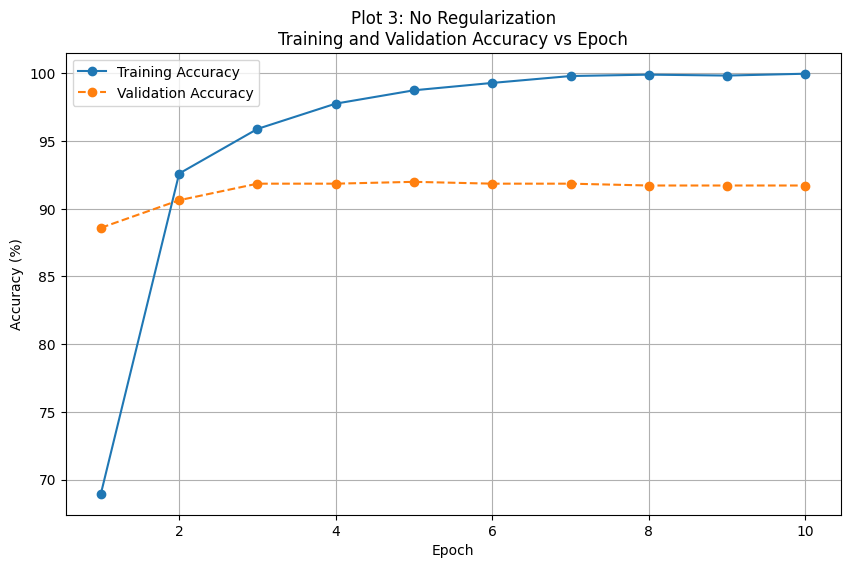

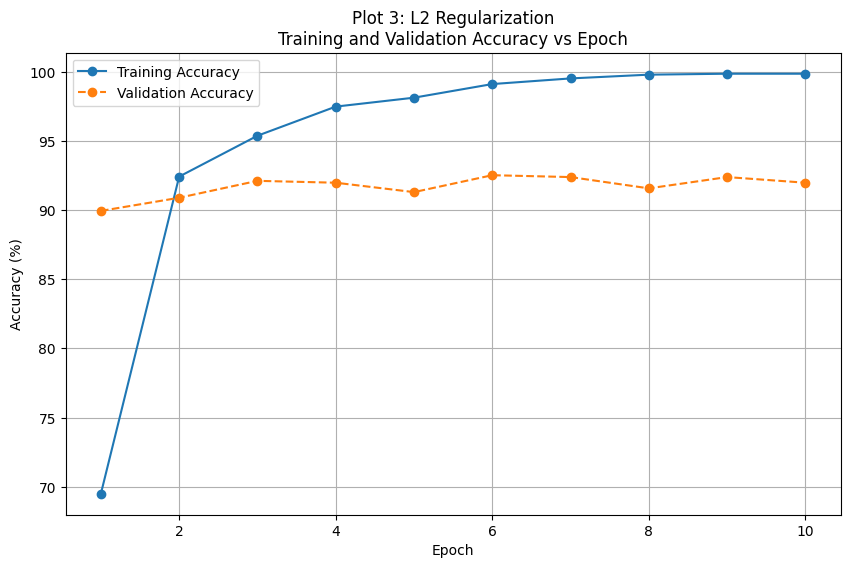

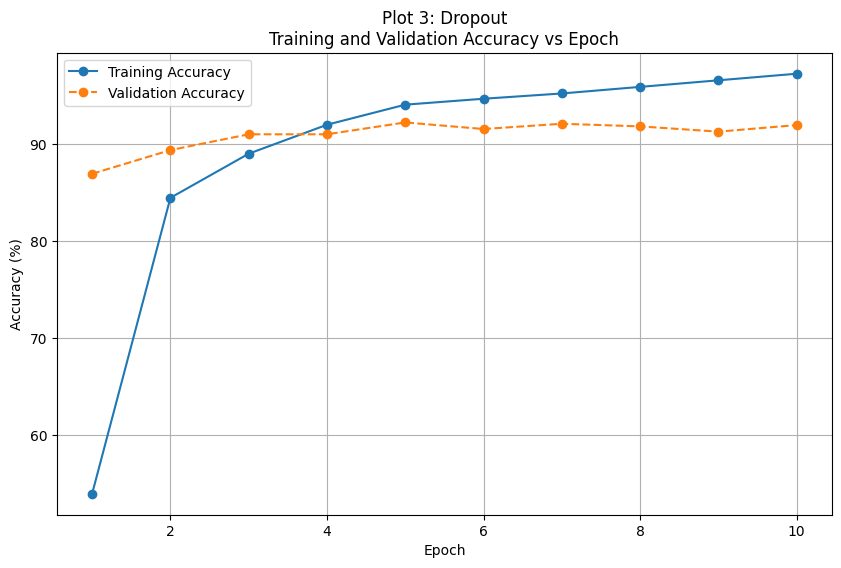

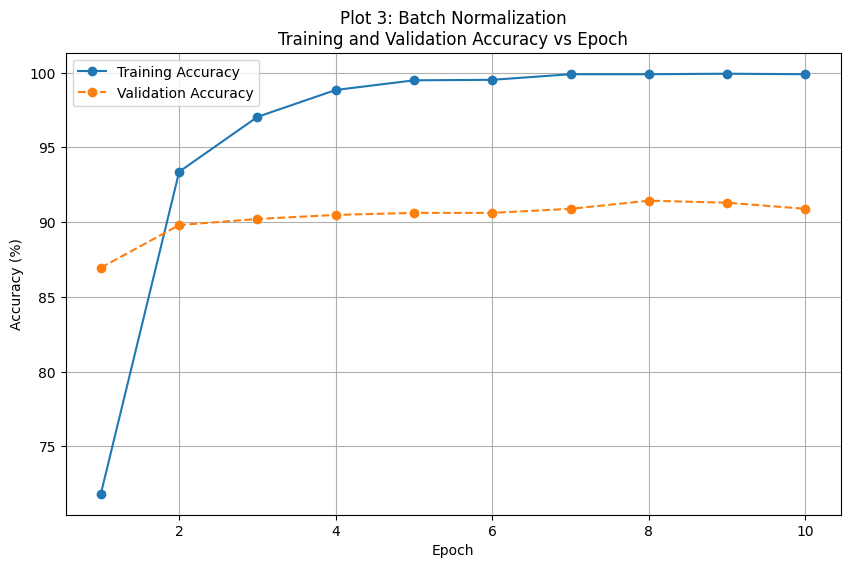

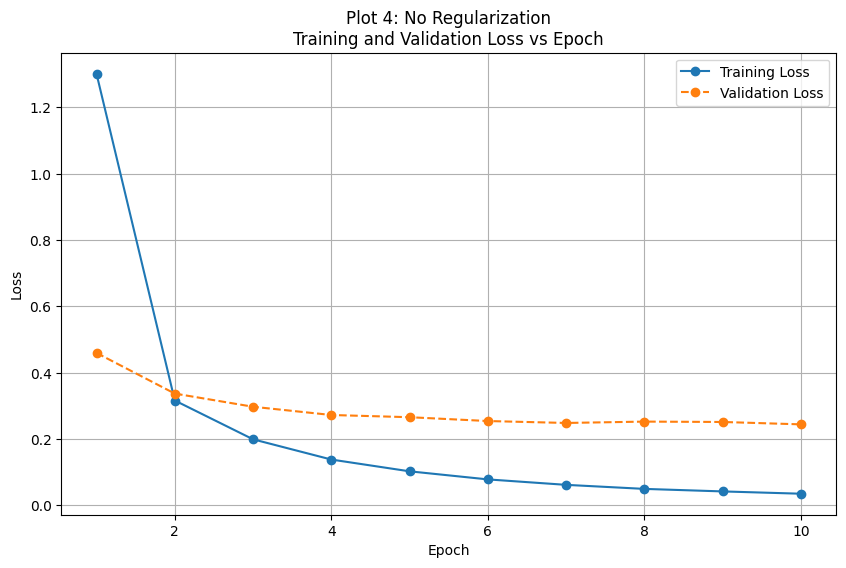

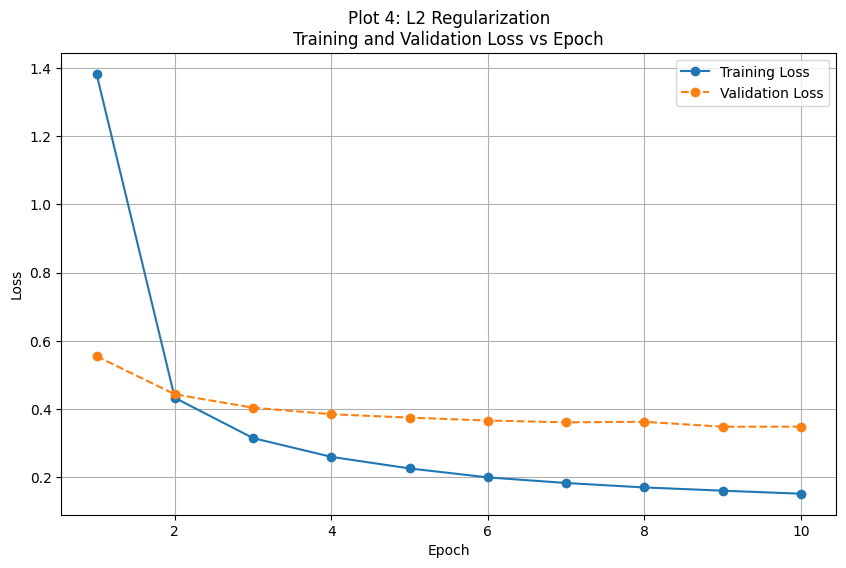

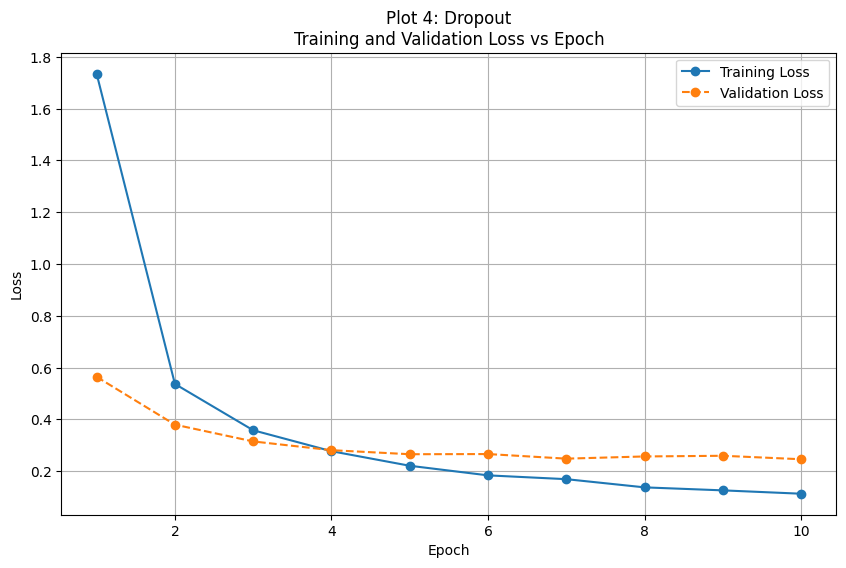

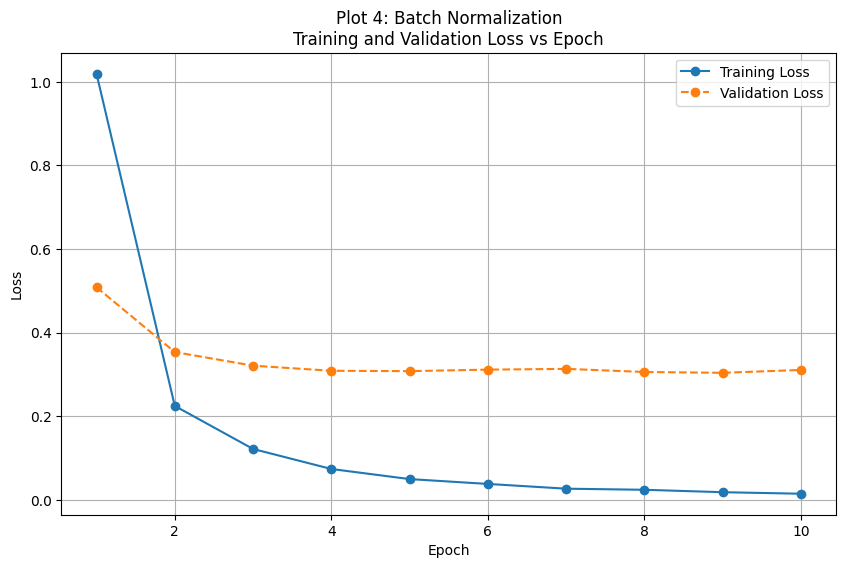


GENERALIZATION GAP AND OVERFITTING ANALYSIS

Method: No Regularization
Final Training Accuracy: 99.97 %
Final Validation Accuracy: 91.71 %
Generalization Gap: 8.25 %
Minimum Validation Loss Epoch: 10
Analysis: Moderate generalization gap.
Analysis: Validation loss continued improving until the final epoch.

Method: L2 Regularization
Final Training Accuracy: 99.86 %
Final Validation Accuracy: 91.98 %
Generalization Gap: 7.88 %
Minimum Validation Loss Epoch: 9
Analysis: Moderate generalization gap.
Analysis: Validation loss reached its minimum before the final epoch.
If training loss continued decreasing after this point while validation loss increased, the model shows overfitting.

Method: Dropout
Final Training Accuracy: 97.28 %
Final Validation Accuracy: 91.98 %
Generalization Gap: 5.3 %
Minimum Validation Loss Epoch: 10
Analysis: Moderate generalization gap.
Analysis: Validation loss continued improving until the final epoch.

Method: Batch Normalization
Final Training Accuracy: 99.

In [ ]:
# ============================================================
# 6. REGULARIZATION AND OVERFITTING
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers, regularizers


# ------------------------------------------------------------
# 1. EXPERIMENT SETTINGS
# ------------------------------------------------------------

EPOCHS = 10
LEARNING_RATE = 0.001

regularization_methods = [
    "No Regularization",
    "L2 Regularization",
    "Dropout",
    "Batch Normalization"
]


# ------------------------------------------------------------
# 2. FUNCTION TO CREATE THE MODEL
# ------------------------------------------------------------

def create_regularization_model(method):

    # Load pretrained MobileNetV2
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained layers
    base_model.trainable = False

    # Input layer
    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # MobileNetV2 feature extraction
    x = base_model(
        inputs,
        training=False
    )

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)


    # ========================================================
    # NO REGULARIZATION
    # ========================================================

    if method == "No Regularization":

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )(x)


    # ========================================================
    # L2 REGULARIZATION
    # ========================================================

    elif method == "L2 Regularization":

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax",
            kernel_regularizer=regularizers.l2(0.001)
        )(x)


    # ========================================================
    # DROPOUT
    # ========================================================

    elif method == "Dropout":

        x = layers.Dropout(
            rate=0.5
        )(x)

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )(x)


    # ========================================================
    # BATCH NORMALIZATION
    # ========================================================

    elif method == "Batch Normalization":

        x = layers.BatchNormalization()(x)

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )(x)


    # Create model
    model = keras.Model(
        inputs=inputs,
        outputs=outputs
    )


    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# 3. TRAIN ALL FOUR MODELS
# ------------------------------------------------------------

histories = {}

for method in regularization_methods:

    print("\n" + "=" * 70)
    print("TRAINING:", method)
    print("=" * 70)

    # Clear previous model from memory
    keras.backend.clear_session()

    # Create model
    model = create_regularization_model(method)

    # Train model
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    # Store history
    histories[method] = history.history


# ============================================================
# 4. PLOT 3
# TRAINING AND VALIDATION ACCURACY VS EPOCH
# ============================================================

for method, history in histories.items():

    epochs_range = range(
        1,
        len(history["accuracy"]) + 1
    )

    plt.figure(figsize=(10, 6))

    # Training Accuracy
    plt.plot(
        epochs_range,
        np.array(history["accuracy"]) * 100,
        marker="o",
        label="Training Accuracy"
    )

    # Validation Accuracy
    plt.plot(
        epochs_range,
        np.array(history["val_accuracy"]) * 100,
        marker="o",
        linestyle="--",
        label="Validation Accuracy"
    )

    plt.title(
        "Plot 3: " +
        method +
        "\nTraining and Validation Accuracy vs Epoch"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")

    plt.legend()
    plt.grid(True)

    plt.show()


# ============================================================
# 5. PLOT 4
# TRAINING AND VALIDATION LOSS VS EPOCH
# ============================================================

for method, history in histories.items():

    epochs_range = range(
        1,
        len(history["loss"]) + 1
    )

    plt.figure(figsize=(10, 6))

    # Training Loss
    plt.plot(
        epochs_range,
        history["loss"],
        marker="o",
        label="Training Loss"
    )

    # Validation Loss
    plt.plot(
        epochs_range,
        history["val_loss"],
        marker="o",
        linestyle="--",
        label="Validation Loss"
    )

    plt.title(
        "Plot 4: " +
        method +
        "\nTraining and Validation Loss vs Epoch"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()
    plt.grid(True)

    plt.show()


# ============================================================
# 6. GENERALIZATION GAP AND OVERFITTING ANALYSIS
# ============================================================

print("\n" + "=" * 80)
print("GENERALIZATION GAP AND OVERFITTING ANALYSIS")
print("=" * 80)


for method, history in histories.items():

    # Final Training Accuracy
    train_accuracy = (
        history["accuracy"][-1] * 100
    )

    # Final Validation Accuracy
    validation_accuracy = (
        history["val_accuracy"][-1] * 100
    )

    # Generalization Gap
    generalization_gap = (
        train_accuracy - validation_accuracy
    )

    # Epoch with minimum validation loss
    minimum_validation_loss_epoch = (
        np.argmin(history["val_loss"]) + 1
    )

    print("\nMethod:", method)

    print(
        "Final Training Accuracy:",
        round(train_accuracy, 2),
        "%"
    )

    print(
        "Final Validation Accuracy:",
        round(validation_accuracy, 2),
        "%"
    )

    print(
        "Generalization Gap:",
        round(generalization_gap, 2),
        "%"
    )

    print(
        "Minimum Validation Loss Epoch:",
        minimum_validation_loss_epoch
    )


    # Generalization Gap Analysis
    if generalization_gap > 10:

        print(
            "Analysis: Large generalization gap "
            "- possible overfitting."
        )

    elif generalization_gap > 5:

        print(
            "Analysis: Moderate generalization gap."
        )

    else:

        print(
            "Analysis: Small generalization gap "
            "- better generalization."
        )


    # Overfitting Analysis
    if minimum_validation_loss_epoch < EPOCHS:

        print(
            "Analysis: Validation loss reached its minimum "
            "before the final epoch."
        )

        print(
            "If training loss continued decreasing after this "
            "point while validation loss increased, "
            "the model shows overfitting."
        )

    else:

        print(
            "Analysis: Validation loss continued improving "
            "until the final epoch."
        )


print("\n" + "=" * 80)
print("REGULARIZATION AND OVERFITTING EXPERIMENT COMPLETED")
print("=" * 80)


TRAINING WITHOUT BATCH NORMALIZATION
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 188ms/step - accuracy: 0.6824 - loss: 1.3121 - val_accuracy: 0.8913 - val_loss: 0.4683
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9273 - loss: 0.3159 - val_accuracy: 0.9171 - val_loss: 0.3219
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.9599 - loss: 0.1985 - val_accuracy: 0.9117 - val_loss: 0.2879
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9779 - loss: 0.1386 - val_accuracy: 0.9185 - val_loss: 0.2609
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.9881 - loss: 0.1016 - val_accuracy: 0.9185 - val_loss: 0.2518
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9932 - loss: 0.0780 - val_accuracy: 0.9185 - val_loss: 0.2512
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.9966 - loss: 0.0614 - val_accuracy: 0.9171 - val_loss: 0.2437
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.99

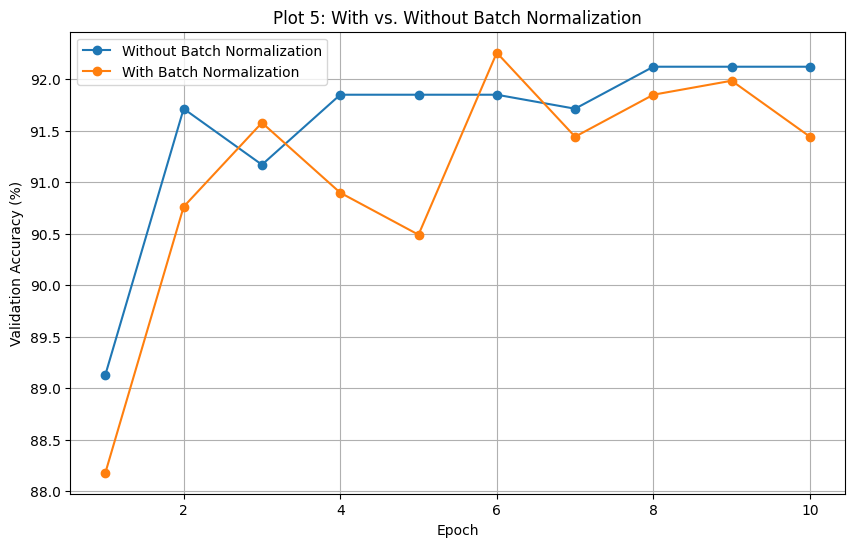


BATCH NORMALIZATION RESULTS

WITHOUT BATCH NORMALIZATION
Final Validation Accuracy: 92.12 %
Best Validation Accuracy: 92.12 %

WITH BATCH NORMALIZATION
Final Validation Accuracy: 91.44 %
Best Validation Accuracy: 92.26 %

CONCLUSION
Batch Normalization achieved better validation accuracy in this experiment.

Best Accuracy Without BN: 92.12 %
Best Accuracy With BN: 92.26 %


In [ ]:
# ============================================================
# 7. BATCH NORMALIZATION EXPERIMENT
# ============================================================
#
# Compare:
# 1. Without Batch Normalization
# 2. With Batch Normalization
#
# Plot 5:
# With vs. Without Batch Normalization
#
# X-axis: Epoch
# Y-axis: Validation Accuracy (%)
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers


# ------------------------------------------------------------
# 2. EXPERIMENT SETTINGS
# ------------------------------------------------------------

EPOCHS = 10
LEARNING_RATE = 0.001
SEED = 42

keras.utils.set_random_seed(SEED)


# ------------------------------------------------------------
# 3. FUNCTION TO CREATE MODEL
# ------------------------------------------------------------

def create_model(use_batch_normalization=False):

    # Load pretrained MobileNetV2
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained MobileNetV2 layers
    base_model.trainable = False


    # Input layer
    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    )


    # MobileNetV2 feature extraction
    x = base_model(
        inputs,
        training=False
    )


    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)


    # --------------------------------------------------------
    # WITH BATCH NORMALIZATION
    # --------------------------------------------------------

    if use_batch_normalization:

        x = layers.BatchNormalization(
            name="batch_normalization"
        )(x)


    # Classification layer
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    # Create model
    model = keras.Model(
        inputs=inputs,
        outputs=outputs
    )


    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )


    return model


# ============================================================
# 4. TRAIN MODEL WITHOUT BATCH NORMALIZATION
# ============================================================

print("\n" + "=" * 70)
print("TRAINING WITHOUT BATCH NORMALIZATION")
print("=" * 70)


keras.backend.clear_session()

keras.utils.set_random_seed(SEED)


model_without_bn = create_model(
    use_batch_normalization=False
)


history_without_bn = model_without_bn.fit(
    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    verbose=1
)


# ============================================================
# 5. TRAIN MODEL WITH BATCH NORMALIZATION
# ============================================================

print("\n" + "=" * 70)
print("TRAINING WITH BATCH NORMALIZATION")
print("=" * 70)


keras.backend.clear_session()

keras.utils.set_random_seed(SEED)


model_with_bn = create_model(
    use_batch_normalization=True
)


history_with_bn = model_with_bn.fit(
    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    verbose=1
)


# ============================================================
# 6. PLOT 5
# WITH VS. WITHOUT BATCH NORMALIZATION
# ============================================================

epochs_range = range(
    1,
    EPOCHS + 1
)


plt.figure(
    figsize=(10, 6)
)


# Validation Accuracy Without BN

plt.plot(
    epochs_range,

    np.array(
        history_without_bn.history[
            "val_accuracy"
        ]
    ) * 100,

    marker="o",

    label="Without Batch Normalization"
)


# Validation Accuracy With BN

plt.plot(
    epochs_range,

    np.array(
        history_with_bn.history[
            "val_accuracy"
        ]
    ) * 100,

    marker="o",

    label="With Batch Normalization"
)


plt.title(
    "Plot 5: With vs. Without Batch Normalization"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Validation Accuracy (%)"
)


plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 7. RESULTS COMPARISON
# ============================================================

final_accuracy_without_bn = (
    history_without_bn.history[
        "val_accuracy"
    ][-1]
    *
    100
)


final_accuracy_with_bn = (
    history_with_bn.history[
        "val_accuracy"
    ][-1]
    *
    100
)


best_accuracy_without_bn = (
    max(
        history_without_bn.history[
            "val_accuracy"
        ]
    )
    *
    100
)


best_accuracy_with_bn = (
    max(
        history_with_bn.history[
            "val_accuracy"
        ]
    )
    *
    100
)


print("\n" + "=" * 70)
print("BATCH NORMALIZATION RESULTS")
print("=" * 70)


print(
    "\nWITHOUT BATCH NORMALIZATION"
)

print(
    "Final Validation Accuracy:",
    round(
        final_accuracy_without_bn,
        2
    ),
    "%"
)

print(
    "Best Validation Accuracy:",
    round(
        best_accuracy_without_bn,
        2
    ),
    "%"
)


print(
    "\nWITH BATCH NORMALIZATION"
)

print(
    "Final Validation Accuracy:",
    round(
        final_accuracy_with_bn,
        2
    ),
    "%"
)

print(
    "Best Validation Accuracy:",
    round(
        best_accuracy_with_bn,
        2
    ),
    "%"
)


# ============================================================
# 8. FINAL CONCLUSION
# ============================================================

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)


if best_accuracy_with_bn > best_accuracy_without_bn:

    print(
        "Batch Normalization achieved better "
        "validation accuracy in this experiment."
    )

elif best_accuracy_with_bn < best_accuracy_without_bn:

    print(
        "The model without Batch Normalization achieved "
        "better validation accuracy in this experiment."
    )

else:

    print(
        "Both models achieved similar validation accuracy."
    )


print("\nBest Accuracy Without BN:",
      round(best_accuracy_without_bn, 2), "%")

print("Best Accuracy With BN:",
      round(best_accuracy_with_bn, 2), "%")

print("=" * 70)


TRAINING WITH: SGD
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.0357 - loss: 3.8399 - val_accuracy: 0.0340 - val_loss: 3.7388
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.0645 - loss: 3.5248 - val_accuracy: 0.0666 - val_loss: 3.4481
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.1175 - loss: 3.2485 - val_accuracy: 0.1291 - val_loss: 3.1882
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.1957 - loss: 2.9995 - val_accuracy: 0.2079 - val_loss: 2.9510
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.2948 - loss: 2.7716 - val_accuracy: 0.3071 - val_loss: 2.7319
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.3845 - loss: 2.5620 - val_accuracy: 0.3995 - val_loss: 2.5300
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.4711 - loss: 2.3695 - val_accuracy: 0.4986 - val_loss: 2.3439
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.5554 - loss: 2.19

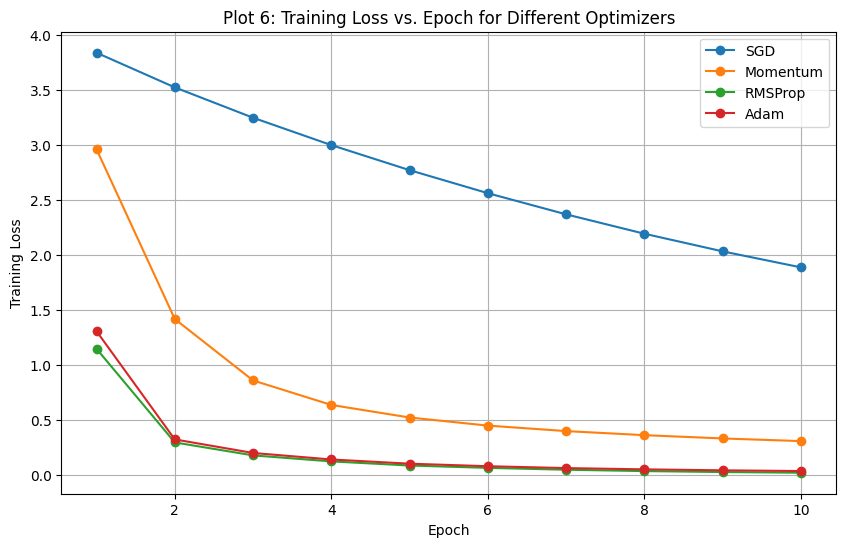

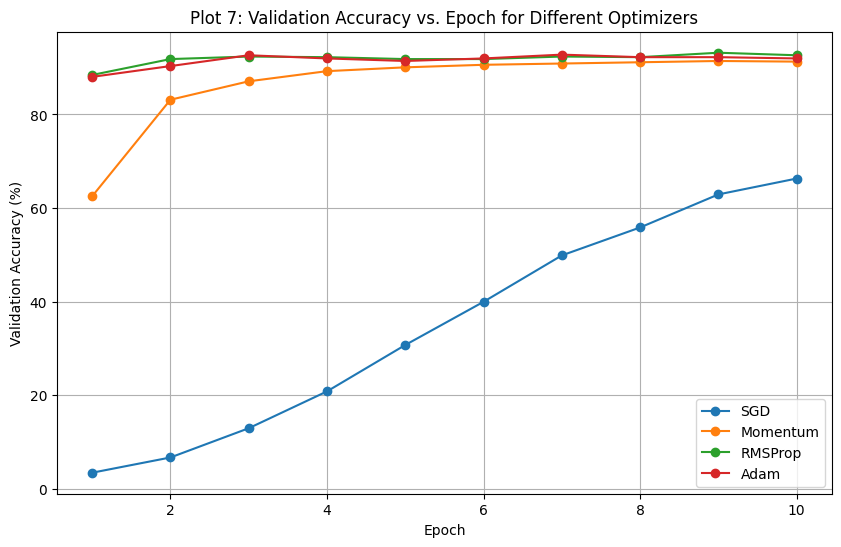


OPTIMIZER COMPARISON RESULTS
Optimizer      Final Loss     Best Val Acc (%)    Epoch to Converge     Time (sec)     
----------------------------------------------------------------------------------------------------
SGD            1.8872         66.30               10                    105.35         
Momentum       0.3070         91.44               10                    113.07         
RMSProp        0.0194         93.21               10                    112.00         
Adam           0.0348         92.80               10                    107.09         

OPTIMIZATION ANALYSIS

Best Validation Performance: RMSProp
Best Validation Accuracy: 93.21 %

Lowest Final Training Loss: RMSProp
Final Loss: 0.0194

Fastest Convergence: SGD
Converged at Epoch: 10

EXPERIMENT COMPLETED


In [ ]:
# ============================================================
# 8. OPTIMIZATION ALGORITHMS
# ============================================================
#
# Compare:
# 1. SGD
# 2. Momentum
# 3. RMSProp
# 4. Adam
#
# Plot 6: Training Loss vs. Epoch
# Plot 7: Validation Accuracy vs. Epoch
#
# Comparison:
# Optimizer | Final Loss | Best Val Accuracy |
# Epoch to Converge | Time
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow import keras
from tensorflow.keras import layers


# ------------------------------------------------------------
# 2. EXPERIMENT SETTINGS
# ------------------------------------------------------------

EPOCHS = 10
LEARNING_RATE = 0.001
SEED = 42

keras.utils.set_random_seed(SEED)


# ------------------------------------------------------------
# 3. DEFINE OPTIMIZERS
# ------------------------------------------------------------

optimizer_configs = {

    "SGD": lambda: keras.optimizers.SGD(
        learning_rate=LEARNING_RATE
    ),

    "Momentum": lambda: keras.optimizers.SGD(
        learning_rate=LEARNING_RATE,
        momentum=0.9
    ),

    "RMSProp": lambda: keras.optimizers.RMSprop(
        learning_rate=LEARNING_RATE
    ),

    "Adam": lambda: keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    )
}


# ------------------------------------------------------------
# 4. CREATE THE SAME MOBILENETV2 MODEL
# ------------------------------------------------------------

def create_optimizer_model(optimizer):

    # Load pretrained MobileNetV2
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained layers
    base_model.trainable = False


    # Input Layer
    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    )


    # Feature Extraction
    x = base_model(
        inputs,
        training=False
    )


    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)


    # Classification Layer
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    # Create Model
    model = keras.Model(
        inputs=inputs,
        outputs=outputs
    )


    # Compile Model
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    return model


# ------------------------------------------------------------
# 5. TRAIN WITH ALL OPTIMIZERS
# ------------------------------------------------------------

histories = {}
results = {}


for optimizer_name, optimizer_function in optimizer_configs.items():

    print("\n" + "=" * 70)
    print("TRAINING WITH:", optimizer_name)
    print("=" * 70)


    # Clear memory
    keras.backend.clear_session()


    # Set same seed for fair comparison
    keras.utils.set_random_seed(SEED)


    # Create a new optimizer
    optimizer = optimizer_function()


    # Create model
    model = create_optimizer_model(
        optimizer
    )


    # Start timer
    start_time = time.time()


    # Train model
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )


    # End timer
    end_time = time.time()


    # Calculate training time
    training_time = end_time - start_time


    # Save history
    histories[optimizer_name] = history.history


    # --------------------------------------------------------
    # FINAL LOSS
    # --------------------------------------------------------

    final_loss = history.history[
        "loss"
    ][-1]


    # --------------------------------------------------------
    # BEST VALIDATION ACCURACY
    # --------------------------------------------------------

    best_val_accuracy = (
        max(
            history.history[
                "val_accuracy"
            ]
        )
        * 100
    )


    # --------------------------------------------------------
    # EPOCH TO CONVERGE
    # --------------------------------------------------------
    # Defined as the epoch at which the minimum
    # training loss was reached.
    # --------------------------------------------------------

    epoch_to_converge = (
        np.argmin(
            history.history[
                "loss"
            ]
        )
        + 1
    )


    # Save results
    results[optimizer_name] = {
        "Final Loss": final_loss,
        "Best Val Accuracy": best_val_accuracy,
        "Epoch to Converge": epoch_to_converge,
        "Time": training_time
    }


# ============================================================
# 6. PLOT 6:
# TRAINING LOSS VS EPOCH FOR DIFFERENT OPTIMIZERS
# ============================================================

plt.figure(figsize=(10, 6))


for optimizer_name, history in histories.items():

    plt.plot(
        range(
            1,
            len(history["loss"]) + 1
        ),

        history["loss"],

        marker="o",

        label=optimizer_name
    )


plt.title(
    "Plot 6: Training Loss vs. Epoch for Different Optimizers"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Training Loss"
)


plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 7. PLOT 7:
# VALIDATION ACCURACY VS EPOCH FOR DIFFERENT OPTIMIZERS
# ============================================================

plt.figure(figsize=(10, 6))


for optimizer_name, history in histories.items():

    plt.plot(
        range(
            1,
            len(history["val_accuracy"]) + 1
        ),

        np.array(
            history["val_accuracy"]
        ) * 100,

        marker="o",

        label=optimizer_name
    )


plt.title(
    "Plot 7: Validation Accuracy vs. Epoch for Different Optimizers"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Validation Accuracy (%)"
)


plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 8. FINAL RESULTS TABLE
# ============================================================

print("\n" + "=" * 100)
print("OPTIMIZER COMPARISON RESULTS")
print("=" * 100)


print(
    f"{'Optimizer':<15}"
    f"{'Final Loss':<15}"
    f"{'Best Val Acc (%)':<20}"
    f"{'Epoch to Converge':<22}"
    f"{'Time (sec)':<15}"
)


print("-" * 100)


for optimizer_name, result in results.items():

    print(
        f"{optimizer_name:<15}"
        f"{result['Final Loss']:<15.4f}"
        f"{result['Best Val Accuracy']:<20.2f}"
        f"{result['Epoch to Converge']:<22}"
        f"{result['Time']:<15.2f}"
    )


print("=" * 100)


# ============================================================
# 9. ANALYSIS
# ============================================================


# Optimizer with best validation accuracy
best_optimizer = max(
    results,
    key=lambda name:
    results[name][
        "Best Val Accuracy"
    ]
)


# Optimizer with lowest final loss
lowest_loss_optimizer = min(
    results,
    key=lambda name:
    results[name][
        "Final Loss"
    ]
)


# Optimizer that converged earliest
fastest_optimizer = min(
    results,
    key=lambda name:
    results[name][
        "Epoch to Converge"
    ]
)


print("\n" + "=" * 70)
print("OPTIMIZATION ANALYSIS")
print("=" * 70)


print(
    "\nBest Validation Performance:",
    best_optimizer
)


print(
    "Best Validation Accuracy:",
    round(
        results[best_optimizer][
            "Best Val Accuracy"
        ],
        2
    ),
    "%"
)


print(
    "\nLowest Final Training Loss:",
    lowest_loss_optimizer
)


print(
    "Final Loss:",
    round(
        results[lowest_loss_optimizer][
            "Final Loss"
        ],
        4
    )
)


print(
    "\nFastest Convergence:",
    fastest_optimizer
)


print(
    "Converged at Epoch:",
    results[fastest_optimizer][
        "Epoch to Converge"
    ]
)


print("\n" + "=" * 70)
print("EXPERIMENT COMPLETED")
print("=" * 70)


LEARNING RATE TUNING

Testing Learning Rate: 0.001
Best Validation Accuracy: 91.17 %

Testing Learning Rate: 0.0001
Best Validation Accuracy: 84.38 %

BATCH SIZE TUNING

Testing Batch Size: 16
Best Validation Accuracy: 87.23 %

Testing Batch Size: 32
Best Validation Accuracy: 84.38 %

Testing Batch Size: 64
Best Validation Accuracy: 75.54 %

DROPOUT RATE TUNING

Testing Dropout Rate: 0
Best Validation Accuracy: 85.19 %

Testing Dropout Rate: 0.25
Best Validation Accuracy: 84.38 %

Testing Dropout Rate: 0.5
Best Validation Accuracy: 82.47 %


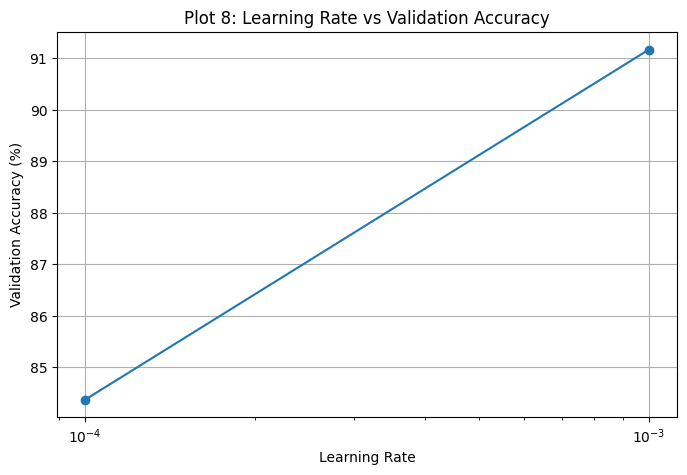

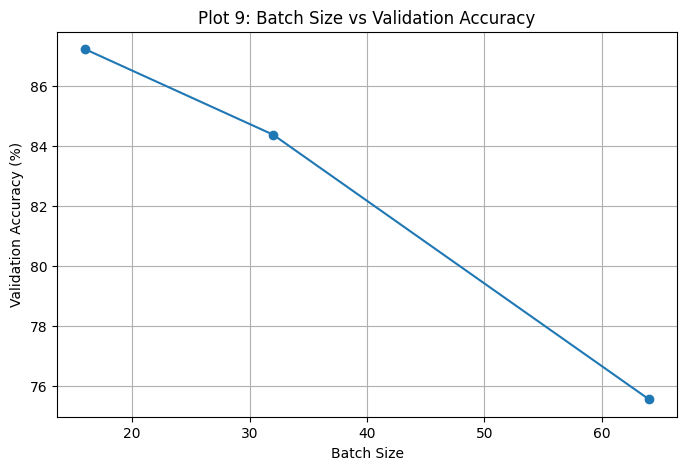

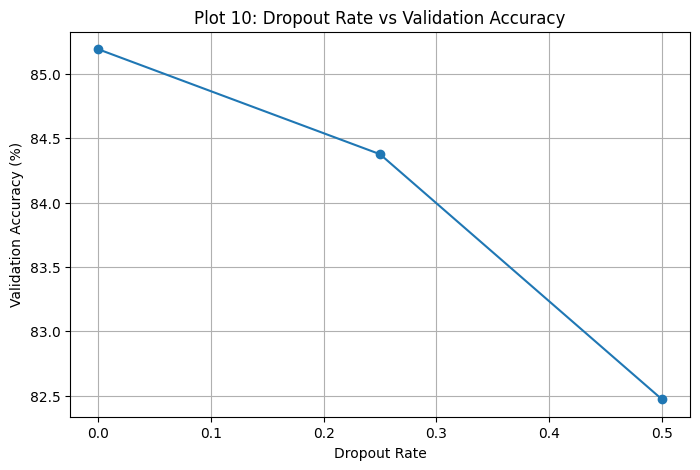


FINAL HYPERPARAMETER TUNING RESULTS

BEST LEARNING RATE: 0.001 - 91.17 %

BEST BATCH SIZE: 16 - 87.23 %

BEST DROPOUT RATE: 0 - 85.19 %

HYPERPARAMETER TUNING COMPLETED


In [ ]:
# ============================================================
# 9. CNN HYPERPARAMETER TUNING
# ============================================================
#
# Controlled Hyperparameter Study
#
# Hyperparameters Investigated:
# 1. Learning Rate: 0.001, 0.0001
# 2. Batch Size: 16, 32, 64
# 3. Dropout Rate: 0, 0.25, 0.5
#
# Fixed Settings:
# - Optimizer: Adam
# - Batch Size: 32 (except Batch Size experiment)
# - Learning Rate: 0.0001 (except Learning Rate experiment)
# - Dropout Rate: 0.25 (except Dropout experiment)
#
# Experimental Rule:
# Change only one hyperparameter at a time.
#
# Output:
# Plot 8: Learning Rate vs Validation Accuracy
# Plot 9: Batch Size vs Validation Accuracy
# Plot 10: Dropout Rate vs Validation Accuracy
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import gc

from tensorflow import keras
from tensorflow.keras import layers


# ------------------------------------------------------------
# 2. EXPERIMENT SETTINGS
# ------------------------------------------------------------

IMG_SIZE = 224
NUM_CLASSES = 37
EPOCHS = 5
SEED = 42

keras.utils.set_random_seed(SEED)


# ------------------------------------------------------------
# 3. FIXED BASELINE VALUES
# ------------------------------------------------------------

BASELINE_LEARNING_RATE = 0.0001
BASELINE_BATCH_SIZE = 32
BASELINE_DROPOUT_RATE = 0.25


# ------------------------------------------------------------
# 4. DATA PREPROCESSING FUNCTION
# ------------------------------------------------------------

def preprocess_image(image_path, label):

    # Read image
    image = tf.io.read_file(image_path)

    # Decode RGB image
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Convert image to float
    image = tf.cast(
        image,
        tf.float32
    )

    # Resize image
    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    # MobileNetV2 preprocessing
    image = tf.keras.applications.mobilenet_v2.preprocess_input(
        image
    )

    return image, label


# ------------------------------------------------------------
# 5. CREATE DATASET
# ------------------------------------------------------------

def create_dataset(
    image_paths,
    labels,
    batch_size,
    training=False
):

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            image_paths,
            labels
        )
    )

    # Shuffle only training dataset
    if training:

        dataset = dataset.shuffle(
            buffer_size=len(image_paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    # Preprocess images
    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Batch dataset
    dataset = dataset.batch(
        batch_size
    )

    # Prefetch data
    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


# ------------------------------------------------------------
# 6. CREATE MOBILENETV2 MODEL
# ------------------------------------------------------------

def create_model(
    learning_rate,
    dropout_rate
):

    # Load pretrained MobileNetV2
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    # Keep base frozen
    base_model.trainable = False


    # Input
    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    )


    # MobileNetV2 feature extraction
    x = base_model(
        inputs,
        training=False
    )


    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)


    # Dropout
    if dropout_rate > 0:

        x = layers.Dropout(
            dropout_rate
        )(x)


    # Output layer
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    # Create model
    model = keras.Model(
        inputs=inputs,
        outputs=outputs
    )


    # Compile model
    model.compile(

        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )


    return model


# ------------------------------------------------------------
# 7. TRAINING FUNCTION
# ------------------------------------------------------------

def run_experiment(
    learning_rate,
    batch_size,
    dropout_rate
):

    # Clear previous session
    keras.backend.clear_session()

    gc.collect()

    # Set seed for fair comparison
    keras.utils.set_random_seed(SEED)


    # Create datasets with selected batch size
    train_dataset = create_dataset(

        train_paths,
        train_labels,

        batch_size=batch_size,

        training=True
    )


    validation_dataset = create_dataset(

        val_paths,
        val_labels,

        batch_size=batch_size,

        training=False
    )


    # Create model
    model = create_model(

        learning_rate=learning_rate,

        dropout_rate=dropout_rate
    )


    # Train model
    history = model.fit(

        train_dataset,

        validation_data=validation_dataset,

        epochs=EPOCHS,

        verbose=0
    )


    # Best validation accuracy
    best_validation_accuracy = (

        max(
            history.history[
                "val_accuracy"
            ]
        )

        * 100

    )


    # Clean memory
    del model

    keras.backend.clear_session()

    gc.collect()


    return best_validation_accuracy


# ============================================================
# 8. EXPERIMENT 1:
# LEARNING RATE TUNING
# ============================================================

learning_rates = [
    0.001,
    0.0001
]

learning_rate_results = {}


print("\n" + "=" * 70)
print("LEARNING RATE TUNING")
print("=" * 70)


for learning_rate in learning_rates:

    print(
        "\nTesting Learning Rate:",
        learning_rate
    )


    accuracy = run_experiment(

        learning_rate=learning_rate,

        batch_size=BASELINE_BATCH_SIZE,

        dropout_rate=BASELINE_DROPOUT_RATE
    )


    learning_rate_results[
        learning_rate
    ] = accuracy


    print(
        "Best Validation Accuracy:",
        round(accuracy, 2),
        "%"
    )


# ============================================================
# 9. EXPERIMENT 2:
# BATCH SIZE TUNING
# ============================================================

batch_sizes = [
    16,
    32,
    64
]

batch_size_results = {}


print("\n" + "=" * 70)
print("BATCH SIZE TUNING")
print("=" * 70)


for batch_size in batch_sizes:

    print(
        "\nTesting Batch Size:",
        batch_size
    )


    accuracy = run_experiment(

        learning_rate=BASELINE_LEARNING_RATE,

        batch_size=batch_size,

        dropout_rate=BASELINE_DROPOUT_RATE
    )


    batch_size_results[
        batch_size
    ] = accuracy


    print(
        "Best Validation Accuracy:",
        round(accuracy, 2),
        "%"
    )


# ============================================================
# 10. EXPERIMENT 3:
# DROPOUT RATE TUNING
# ============================================================

dropout_rates = [
    0,
    0.25,
    0.5
]

dropout_results = {}


print("\n" + "=" * 70)
print("DROPOUT RATE TUNING")
print("=" * 70)


for dropout_rate in dropout_rates:

    print(
        "\nTesting Dropout Rate:",
        dropout_rate
    )


    accuracy = run_experiment(

        learning_rate=BASELINE_LEARNING_RATE,

        batch_size=BASELINE_BATCH_SIZE,

        dropout_rate=dropout_rate
    )


    dropout_results[
        dropout_rate
    ] = accuracy


    print(
        "Best Validation Accuracy:",
        round(accuracy, 2),
        "%"
    )


# ============================================================
# PLOT 8:
# LEARNING RATE VS VALIDATION ACCURACY
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    list(
        learning_rate_results.keys()
    ),

    list(
        learning_rate_results.values()
    ),

    marker="o"

)


plt.xscale(
    "log"
)


plt.title(
    "Plot 8: Learning Rate vs Validation Accuracy"
)


plt.xlabel(
    "Learning Rate"
)


plt.ylabel(
    "Validation Accuracy (%)"
)


plt.grid(True)

plt.show()


# ============================================================
# PLOT 9:
# BATCH SIZE VS VALIDATION ACCURACY
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    list(
        batch_size_results.keys()
    ),

    list(
        batch_size_results.values()
    ),

    marker="o"

)


plt.title(
    "Plot 9: Batch Size vs Validation Accuracy"
)


plt.xlabel(
    "Batch Size"
)


plt.ylabel(
    "Validation Accuracy (%)"
)


plt.grid(True)

plt.show()


# ============================================================
# PLOT 10:
# DROPOUT RATE VS VALIDATION ACCURACY
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    list(
        dropout_results.keys()
    ),

    list(
        dropout_results.values()
    ),

    marker="o"

)


plt.title(
    "Plot 10: Dropout Rate vs Validation Accuracy"
)


plt.xlabel(
    "Dropout Rate"
)


plt.ylabel(
    "Validation Accuracy (%)"
)


plt.grid(True)

plt.show()


# ============================================================
# 11. FINAL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("FINAL HYPERPARAMETER TUNING RESULTS")
print("=" * 70)


# Best Learning Rate
best_learning_rate = max(

    learning_rate_results,

    key=learning_rate_results.get
)


# Best Batch Size
best_batch_size = max(

    batch_size_results,

    key=batch_size_results.get
)


# Best Dropout Rate
best_dropout_rate = max(

    dropout_results,

    key=dropout_results.get
)


print(

    "\nBEST LEARNING RATE:",

    best_learning_rate,

    "-",

    round(
        learning_rate_results[
            best_learning_rate
        ],
        2
    ),

    "%"
)


print(

    "\nBEST BATCH SIZE:",

    best_batch_size,

    "-",

    round(
        batch_size_results[
            best_batch_size
        ],
        2
    ),

    "%"
)


print(

    "\nBEST DROPOUT RATE:",

    best_dropout_rate,

    "-",

    round(
        dropout_results[
            best_dropout_rate
        ],
        2
    ),

    "%"
)


print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING COMPLETED")
print("=" * 70)


CASE A: FEATURE EXTRACTION
MobileNetV2 Base: FROZEN
Only New Classifier: TRAINED

Trainable layers:
3
Total layers: 4
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.6909 - loss: 1.3008 - val_accuracy: 0.8981 - val_loss: 0.4613
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.9314 - loss: 0.3170 - val_accuracy: 0.9117 - val_loss: 0.3342
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.9630 - loss: 0.1980 - val_accuracy: 0.9171 - val_loss: 0.2829
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.9745 - loss: 0.1406 - val_accuracy: 0.9198 - val_loss: 0.2662
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9861 - loss: 0.1032 - val_accuracy: 0.9130 - val_loss: 0.2594
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.9935 - loss: 0.0777 - val_accuracy: 0.9239 - val_loss: 0.2622
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.9969 - loss: 0.0616 - val_accuracy: 0.9239 - val_l

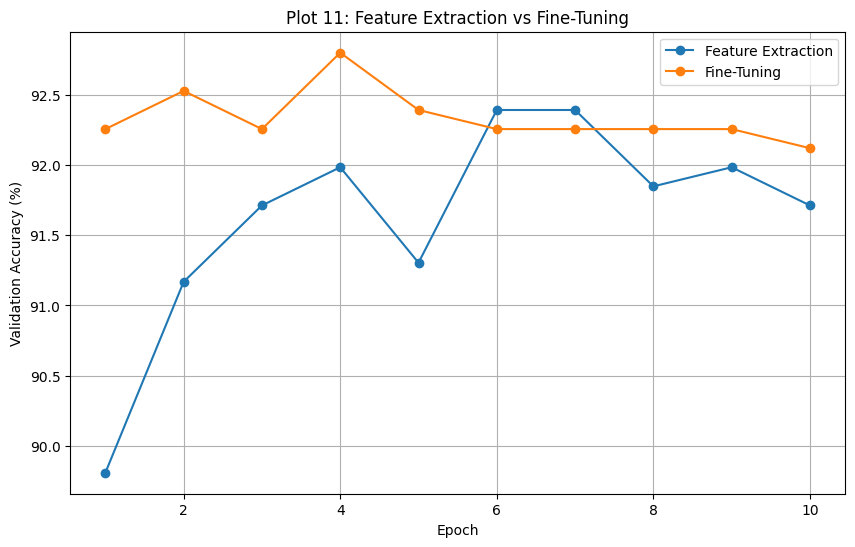

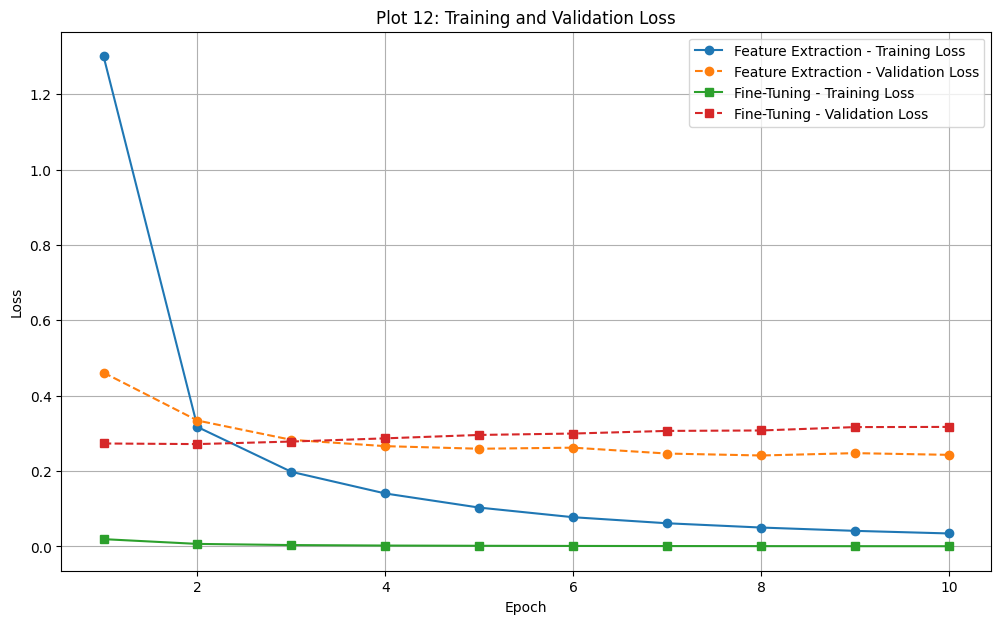


TRANSFER LEARNING AND FINE-TUNING RESULTS

FEATURE EXTRACTION
Best Validation Accuracy: 92.39 %
Final Validation Loss: 0.2431

FINE-TUNING
Best Validation Accuracy: 92.8 %
Final Validation Loss: 0.3173

CONCLUSION

Fine-tuning achieved better validation accuracy.
This suggests that adapting the upper pretrained MobileNetV2 layers to the Oxford-IIIT Pet Dataset improved feature representation.

Why is a smaller learning rate used for fine-tuning?
The pretrained MobileNetV2 layers already contain useful ImageNet features. A large learning rate could rapidly overwrite these learned weights and cause catastrophic forgetting. Therefore, a small learning rate such as 1e-5 allows the network to make small, controlled updates while preserving useful pretrained representations.

EXPERIMENT COMPLETED


In [ ]:
# ============================================================
# 10. TRANSFER LEARNING AND FINE-TUNING
# ============================================================
#
# Case A: Feature Extraction
# MobileNetV2 -> Frozen Base -> New Classifier
#
# Case B: Fine-Tuning
# MobileNetV2 -> Unfreeze Upper Layers -> Small Learning Rate
#
# Plot 11: Feature Extraction vs Fine-Tuning
#           Validation Accuracy vs Epoch
#
# Plot 12: Training and Validation Loss
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import gc

from tensorflow import keras
from tensorflow.keras import layers


# ------------------------------------------------------------
# 2. EXPERIMENT SETTINGS
# ------------------------------------------------------------

EPOCHS_FEATURE_EXTRACTION = 10
EPOCHS_FINE_TUNING = 10

FEATURE_EXTRACTION_LR = 0.001
FINE_TUNING_LR = 0.00001

SEED = 42

keras.utils.set_random_seed(SEED)


# ------------------------------------------------------------
# 3. FUNCTION TO CREATE FEATURE EXTRACTION MODEL
# ------------------------------------------------------------

def create_feature_extraction_model():

    # Load ImageNet pretrained MobileNetV2
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze all pretrained layers
    base_model.trainable = False


    # Input layer
    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    )


    # Extract features
    x = base_model(
        inputs,
        training=False
    )


    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)


    # New classification layer
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="classifier"
    )(x)


    # Create model
    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="feature_extraction_model"
    )


    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=FEATURE_EXTRACTION_LR
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )


    return model


# ============================================================
# 4. CASE A: FEATURE EXTRACTION
# ============================================================

print("\n" + "=" * 70)
print("CASE A: FEATURE EXTRACTION")
print("MobileNetV2 Base: FROZEN")
print("Only New Classifier: TRAINED")
print("=" * 70)


# Clear memory
keras.backend.clear_session()
gc.collect()

# Set seed
keras.utils.set_random_seed(SEED)


# Create feature extraction model
feature_model = create_feature_extraction_model()


# Display trainable status
print("\nTrainable layers:")
print(
    sum(
        layer.trainable
        for layer in feature_model.layers
    )
)

print(
    "Total layers:",
    len(feature_model.layers)
)


# Train feature extraction model
history_feature = feature_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FEATURE_EXTRACTION,
    verbose=1
)


# ============================================================
# 5. CASE B: FINE-TUNING
# ============================================================

print("\n" + "=" * 70)
print("CASE B: FINE-TUNING")
print("Unfreezing Selected Upper Layers")
print("Using Smaller Learning Rate")
print("=" * 70)


# Get MobileNetV2 base model
base_model = feature_model.get_layer(
    "mobilenetv2_1.00_224"
)


# Unfreeze the base model
base_model.trainable = True


# Number of layers to keep frozen
FINE_TUNE_AT = 100


# Freeze lower layers
for layer in base_model.layers[:FINE_TUNE_AT]:

    layer.trainable = False


# Keep Batch Normalization layers frozen
# This provides more stable fine-tuning
for layer in base_model.layers:

    if isinstance(
        layer,
        layers.BatchNormalization
    ):
        layer.trainable = False


# Recompile with smaller learning rate
feature_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=FINE_TUNING_LR
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)


# Display fine-tuning information
trainable_layers = sum(
    layer.trainable
    for layer in base_model.layers
)


print(
    "\nTotal MobileNetV2 Layers:",
    len(base_model.layers)
)

print(
    "Trainable MobileNetV2 Layers:",
    trainable_layers
)

print(
    "Frozen MobileNetV2 Layers:",
    len(base_model.layers) - trainable_layers
)

print(
    "Fine-Tuning Learning Rate:",
    FINE_TUNING_LR
)


# Train fine-tuned model
history_fine_tuning = feature_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS_FINE_TUNING,

    verbose=1

)


# ============================================================
# 6. PLOT 11:
# FEATURE EXTRACTION VS FINE-TUNING
# ============================================================

plt.figure(figsize=(10, 6))


# Feature Extraction Validation Accuracy
plt.plot(

    range(
        1,
        EPOCHS_FEATURE_EXTRACTION + 1
    ),

    np.array(
        history_feature.history[
            "val_accuracy"
        ]
    ) * 100,

    marker="o",

    label="Feature Extraction"

)


# Fine-Tuning Validation Accuracy
plt.plot(

    range(
        1,
        EPOCHS_FINE_TUNING + 1
    ),

    np.array(
        history_fine_tuning.history[
            "val_accuracy"
        ]
    ) * 100,

    marker="o",

    label="Fine-Tuning"

)


plt.title(
    "Plot 11: Feature Extraction vs Fine-Tuning"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation Accuracy (%)"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 7. PLOT 12:
# TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(12, 7))


# Feature Extraction Training Loss
plt.plot(

    range(
        1,
        EPOCHS_FEATURE_EXTRACTION + 1
    ),

    history_feature.history[
        "loss"
    ],

    marker="o",

    linestyle="-",

    label="Feature Extraction - Training Loss"

)


# Feature Extraction Validation Loss
plt.plot(

    range(
        1,
        EPOCHS_FEATURE_EXTRACTION + 1
    ),

    history_feature.history[
        "val_loss"
    ],

    marker="o",

    linestyle="--",

    label="Feature Extraction - Validation Loss"

)


# Fine-Tuning Training Loss
plt.plot(

    range(
        1,
        EPOCHS_FINE_TUNING + 1
    ),

    history_fine_tuning.history[
        "loss"
    ],

    marker="s",

    linestyle="-",

    label="Fine-Tuning - Training Loss"

)


# Fine-Tuning Validation Loss
plt.plot(

    range(
        1,
        EPOCHS_FINE_TUNING + 1
    ),

    history_fine_tuning.history[
        "val_loss"
    ],

    marker="s",

    linestyle="--",

    label="Fine-Tuning - Validation Loss"

)


plt.title(
    "Plot 12: Training and Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 8. FINAL PERFORMANCE COMPARISON
# ============================================================

feature_best_accuracy = (
    max(
        history_feature.history[
            "val_accuracy"
        ]
    )
    * 100
)


fine_tuning_best_accuracy = (
    max(
        history_fine_tuning.history[
            "val_accuracy"
        ]
    )
    * 100
)


feature_final_loss = (
    history_feature.history[
        "val_loss"
    ][-1]
)


fine_tuning_final_loss = (
    history_fine_tuning.history[
        "val_loss"
    ][-1]
)


print("\n" + "=" * 70)
print("TRANSFER LEARNING AND FINE-TUNING RESULTS")
print("=" * 70)


print(
    "\nFEATURE EXTRACTION"
)

print(
    "Best Validation Accuracy:",
    round(
        feature_best_accuracy,
        2
    ),
    "%"
)

print(
    "Final Validation Loss:",
    round(
        feature_final_loss,
        4
    )
)


print(
    "\nFINE-TUNING"
)

print(
    "Best Validation Accuracy:",
    round(
        fine_tuning_best_accuracy,
        2
    ),
    "%"
)

print(
    "Final Validation Loss:",
    round(
        fine_tuning_final_loss,
        4
    )
)


# ============================================================
# 9. FINAL CONCLUSION
# ============================================================

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)


if fine_tuning_best_accuracy > feature_best_accuracy:

    print(
        "\nFine-tuning achieved better validation accuracy."
    )

    print(
        "This suggests that adapting the upper pretrained "
        "MobileNetV2 layers to the Oxford-IIIT Pet Dataset "
        "improved feature representation."
    )

else:

    print(
        "\nFeature extraction achieved equal or better "
        "validation accuracy in this experiment."
    )

    print(
        "The pretrained ImageNet features were already "
        "sufficient for this classification task."
    )


print(
    "\nWhy is a smaller learning rate used for fine-tuning?"
)

print(
    "The pretrained MobileNetV2 layers already contain useful "
    "ImageNet features. A large learning rate could rapidly "
    "overwrite these learned weights and cause catastrophic "
    "forgetting. Therefore, a small learning rate such as "
    "1e-5 allows the network to make small, controlled updates "
    "while preserving useful pretrained representations."
)


print("\n" + "=" * 70)
print("EXPERIMENT COMPLETED")
print("=" * 70)

In [ ]:
# ============================================================
# FINAL DATASET RECOVERY BLOCK
# OXFORD-IIIT PET DATASET
# ============================================================

import tensorflow as tf
import numpy as np
import os
import tarfile
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 37
SEED = 42

print("TensorFlow Version:", tf.__version__)
print("Image Size:", IMG_SIZE, "x", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)
print("Number of Classes:", NUM_CLASSES)


# ============================================================
# 1. DOWNLOAD IMAGES TAR FILE
# ============================================================

images_tar_path = tf.keras.utils.get_file(
    fname="images.tar.gz",
    origin="https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz",
    extract=False
)

print("\nImages archive:")
print(images_tar_path)


# ============================================================
# 2. EXTRACT IMAGES MANUALLY
# ============================================================

dataset_root = os.path.join(
    os.path.dirname(images_tar_path),
    "oxford_pet_dataset"
)

os.makedirs(
    dataset_root,
    exist_ok=True
)

images_dir = os.path.join(
    dataset_root,
    "images"
)

if not os.path.exists(images_dir) or len(os.listdir(images_dir)) == 0:

    print("\nExtracting images...")

    with tarfile.open(
        images_tar_path,
        "r:gz"
    ) as tar:

        tar.extractall(
            dataset_root
        )

else:

    print("\nImages already extracted.")


# ============================================================
# 3. VERIFY IMAGE DIRECTORY
# ============================================================

print("\nChecking image directory...")

print("Images directory:")
print(images_dir)

if not os.path.exists(images_dir):

    raise FileNotFoundError(
        f"Images directory not found:\n{images_dir}"
    )


image_files = [

    f for f in os.listdir(images_dir)

    if f.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )

]

print("Number of image files found:", len(image_files))

if len(image_files) == 0:

    raise ValueError(
        "No images were extracted. "
        "Delete the dataset folder and rerun this cell."
    )

print("Example images:")
print(image_files[:5])


# ============================================================
# 4. DOWNLOAD ANNOTATIONS
# ============================================================

annotations_tar_path = tf.keras.utils.get_file(
    fname="annotations.tar.gz",
    origin="https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz",
    extract=False
)

print("\nAnnotations archive:")
print(annotations_tar_path)


# ============================================================
# 5. EXTRACT ANNOTATIONS MANUALLY
# ============================================================

annotations_root = os.path.join(
    dataset_root,
    "annotations"
)

trainval_file = os.path.join(
    annotations_root,
    "trainval.txt"
)

test_file = os.path.join(
    annotations_root,
    "test.txt"
)


if not os.path.exists(trainval_file):

    print("\nExtracting annotations...")

    with tarfile.open(
        annotations_tar_path,
        "r:gz"
    ) as tar:

        tar.extractall(
            dataset_root
        )

else:

    print("\nAnnotations already extracted.")


# ============================================================
# 6. VERIFY ANNOTATION FILES
# ============================================================

print("\nTrain/Validation file:")
print(trainval_file)

print("\nTest file:")
print(test_file)


if not os.path.exists(trainval_file):

    raise FileNotFoundError(
        f"trainval.txt not found:\n{trainval_file}"
    )


if not os.path.exists(test_file):

    raise FileNotFoundError(
        f"test.txt not found:\n{test_file}"
    )


# ============================================================
# 7. READ ANNOTATION FILES
# ============================================================

def read_annotation_file(annotation_file):

    image_paths = []
    labels = []


    with open(
        annotation_file,
        "r"
    ) as file:

        for line in file:

            line = line.strip()


            if line == "":
                continue


            parts = line.split()


            # First column = image name
            image_name = parts[0]


            # Second column = class label
            # Convert from 1-37 to 0-36
            class_label = int(parts[1]) - 1


            # Create image path
            image_path = os.path.join(
                images_dir,
                image_name + ".jpg"
            )


            # Add only if image exists
            if os.path.exists(image_path):

                image_paths.append(
                    image_path
                )

                labels.append(
                    class_label
                )


    return (
        np.array(image_paths),
        np.array(labels)
    )


# ============================================================
# 8. LOAD TRAIN/VALIDATION DATA
# ============================================================

trainval_paths, trainval_labels = read_annotation_file(
    trainval_file
)


# ============================================================
# 9. LOAD OFFICIAL TEST DATA
# ============================================================

test_paths, test_labels = read_annotation_file(
    test_file
)


# ============================================================
# 10. CHECK DATASET
# ============================================================

print("\n" + "=" * 60)
print("DATASET LOADING RESULTS")
print("=" * 60)

print(
    "Train/Validation Images:",
    len(trainval_paths)
)

print(
    "Official Test Images:",
    len(test_paths)
)


if len(trainval_paths) == 0:

    raise ValueError(
        "0 training images found. "
        "Images and annotation names do not match."
    )


if len(test_paths) == 0:

    raise ValueError(
        "0 test images found. "
        "Images and annotation names do not match."
    )


# ============================================================
# 11. CREATE TRAIN + VALIDATION SPLIT
# ============================================================

train_paths, val_paths, train_labels, val_labels = train_test_split(

    trainval_paths,

    trainval_labels,

    test_size=0.20,

    random_state=SEED,

    stratify=trainval_labels
)


# ============================================================
# 12. CLASS NAMES
# ============================================================

class_names = [

    "Abyssinian",
    "american_bulldog",
    "american_pit_bull_terrier",
    "basset_hound",
    "beagle",
    "Bengal",
    "Birman",
    "Bombay",
    "boxer",
    "British_Shorthair",
    "chihuahua",
    "Egyptian_Mau",
    "english_cocker_spaniel",
    "english_setter",
    "german_shorthaired",
    "great_pyrenees",
    "havanese",
    "japanese_chin",
    "keeshond",
    "leonberger",
    "Maine_Coon",
    "miniature_pinscher",
    "newfoundland",
    "Persian",
    "pomeranian",
    "pug",
    "Ragdoll",
    "Russian_Blue",
    "saint_bernard",
    "samoyed",
    "scottish_terrier",
    "shiba_inu",
    "Siamese",
    "Sphynx",
    "staffordshire_bull_terrier",
    "wheaten_terrier",
    "yorkshire_terrier"
]


# ============================================================
# 13. FINAL VERIFICATION
# ============================================================

print("\n" + "=" * 60)
print("DATASET RECOVERY COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Training Samples  :", len(train_paths))
print("Validation Samples:", len(val_paths))
print("Test Samples      :", len(test_paths))
print("Number of Classes :", NUM_CLASSES)

print("\nExample Training Image:")
print(train_paths[0])

print("Training Label:")
print(train_labels[0])

print("\nALL REQUIRED VARIABLES ARE READY:")
print("✓ train_paths")
print("✓ val_paths")
print("✓ test_paths")
print("✓ train_labels")
print("✓ val_labels")
print("✓ test_labels")
print("✓ IMG_SIZE")
print("✓ NUM_CLASSES")
print("✓ class_names")

TensorFlow Version: 2.20.0
Image Size: 224 x 224
Batch Size: 32
Number of Classes: 37

Images archive:
/root/.keras/datasets/images.tar.gz

Extracting images...


/tmp/ipykernel_26128/491849084.py:69: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(



Checking image directory...
Images directory:
/root/.keras/datasets/oxford_pet_dataset/images
Number of image files found: 7390
Example images:
['pomeranian_156.jpg', 'pug_187.jpg', 'Sphynx_141.jpg', 'boxer_115.jpg', 'pomeranian_36.jpg']

Annotations archive:
/root/.keras/datasets/annotations.tar.gz

Extracting annotations...


/tmp/ipykernel_26128/491849084.py:160: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(



Train/Validation file:
/root/.keras/datasets/oxford_pet_dataset/annotations/trainval.txt

Test file:
/root/.keras/datasets/oxford_pet_dataset/annotations/test.txt

DATASET LOADING RESULTS
Train/Validation Images: 3680
Official Test Images: 3669

DATASET RECOVERY COMPLETED SUCCESSFULLY
Training Samples  : 2944
Validation Samples: 736
Test Samples      : 3669
Number of Classes : 37

Example Training Image:
/root/.keras/datasets/oxford_pet_dataset/images/Sphynx_179.jpg
Training Label:
33

ALL REQUIRED VARIABLES ARE READY:
✓ train_paths
✓ val_paths
✓ test_paths
✓ train_labels
✓ val_labels
✓ test_labels
✓ IMG_SIZE
✓ NUM_CLASSES
✓ class_names


TASK 11: 5-FOLD CROSS-VALIDATION
CV Samples: 3680
Test Samples: 3669
Number of Classes: 37

IMPORTANT:
The independent test set is NOT used in cross-validation.

Starting fresh cross-validation...

RUNNING CONFIGURATION: C1
Learning Rate: 0.001
Batch Size: 32
Dropout Rate: 0.25
Optimizer: Adam

------------------------------------------------------------
C1 - FOLD 1/5
------------------------------------------------------------
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 37s 188ms/step - accuracy: 0.6478 - loss: 1.4213 - val_accuracy: 0.8913 - val_loss: 0.4976
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.9008 - loss: 0.3819 - val_accuracy: 0.9212 - val_loss: 0.3508
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.9297 - loss: 0.2632 - val_accuracy: 0.9171 - val_loss: 0.2979

Fold 1 Best Accuracy: 92.12%

------------------------------------------------------------
C1 - FOLD 2/5
------------------------------------------------------------
Epoch 1/3
92/92 ━━━━━

,Configuration,F1,F2,F3,F4,F5,Mean ± SD,Mean Accuracy,Standard Deviation
0,C1,92.119563,88.722825,89.130437,91.440219,90.081519,90.30 ± 1.30,90.298913,1.304913
1,C2,71.875000,73.913044,69.429350,73.097825,72.418481,72.15 ± 1.52,72.146740,1.520282
2,C3,68.206519,64.266306,67.527175,65.896738,68.206519,66.82 ± 1.53,66.820651,1.530930
3,C4,12.500000,17.934783,20.380434,21.603261,15.896739,17.66 ± 3.25,17.663043,3.248391


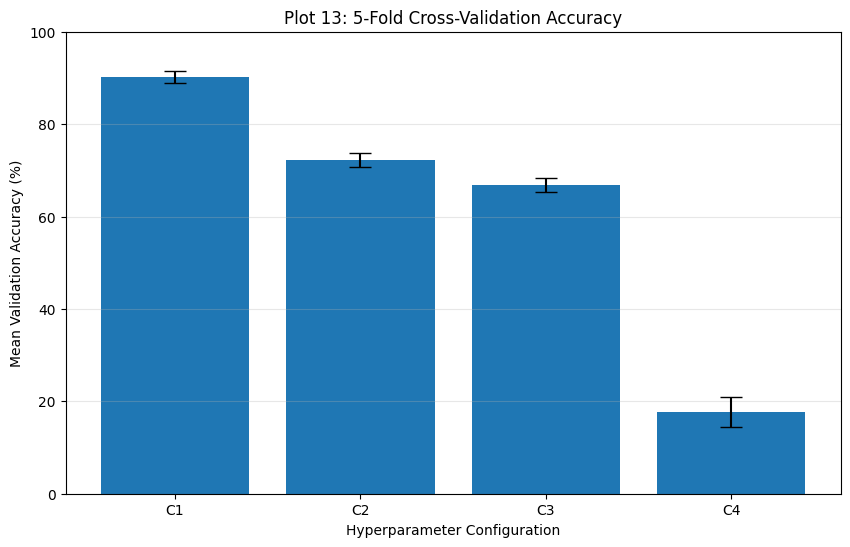


BEST CONFIGURATION
Best Configuration: C1
Learning Rate: 0.001
Batch Size: 32
Dropout Rate: 0.25
Optimizer: Adam

Mean CV Accuracy: 90.30%
CV Standard Deviation: 1.30%

Final CV Result: 90.30 ± 1.30%

Task 11 completed successfully!
Final results saved as:
task11_final_results.pkl


In [ ]:
# ============================================================
# TASK 11: 5-FOLD CROSS-VALIDATION
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import pickle
import gc

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import StratifiedKFold

# ------------------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------------------

SEED = 42
NUM_FOLDS = 5

# Reduce epochs if Colab is running slowly
CV_EPOCHS = 3

keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# 2. USE COMPLETE TRAINING + VALIDATION DATA FOR CV
# ------------------------------------------------------------
# IMPORTANT:
# Official test data is NOT used here.
# ------------------------------------------------------------

cv_paths = np.concatenate([
    np.array(train_paths),
    np.array(val_paths)
])

cv_labels = np.concatenate([
    np.array(train_labels),
    np.array(val_labels)
])

print("=" * 70)
print("TASK 11: 5-FOLD CROSS-VALIDATION")
print("=" * 70)

print("CV Samples:", len(cv_paths))
print("Test Samples:", len(test_paths))
print("Number of Classes:", NUM_CLASSES)

print("\nIMPORTANT:")
print("The independent test set is NOT used in cross-validation.")

# ------------------------------------------------------------
# 3. PROMISING CONFIGURATIONS
# ------------------------------------------------------------

configurations = {

    "C1": {
        "learning_rate": 0.001,
        "batch_size": 32,
        "dropout_rate": 0.25,
        "optimizer": "Adam"
    },

    "C2": {
        "learning_rate": 0.0001,
        "batch_size": 32,
        "dropout_rate": 0.25,
        "optimizer": "Adam"
    },

    "C3": {
        "learning_rate": 0.0001,
        "batch_size": 32,
        "dropout_rate": 0.5,
        "optimizer": "Adam"
    },

    "C4": {
        "learning_rate": 0.001,
        "batch_size": 32,
        "dropout_rate": 0.25,
        "optimizer": "SGD"
    }
}

# ------------------------------------------------------------
# 4. SAVE/LOAD PROGRESS
# ------------------------------------------------------------

SAVE_FILE = "task11_cv_progress.pkl"

# If a previous run exists, continue from it
if os.path.exists(SAVE_FILE):

    with open(SAVE_FILE, "rb") as file:
        saved_data = pickle.load(file)

    all_results = saved_data["all_results"]
    completed_configs = saved_data["completed_configs"]

    print("\nPrevious Task 11 progress found!")
    print("Completed configurations:", completed_configs)

else:

    all_results = {}
    completed_configs = []

    print("\nStarting fresh cross-validation...")

# ------------------------------------------------------------
# 5. IMAGE PREPROCESSING
# ------------------------------------------------------------

def preprocess_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = tf.keras.applications.mobilenet_v2.preprocess_input(
        image
    )

    return image, label


# ------------------------------------------------------------
# 6. CREATE DATASET
# ------------------------------------------------------------

def create_dataset(
    image_paths,
    labels,
    batch_size,
    training=False
):

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    if training:

        dataset = dataset.shuffle(
            buffer_size=len(image_paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(
        batch_size
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


# ------------------------------------------------------------
# 7. GET OPTIMIZER
# ------------------------------------------------------------

def get_optimizer(
    optimizer_name,
    learning_rate
):

    if optimizer_name == "SGD":

        return keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    elif optimizer_name == "Momentum":

        return keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )

    elif optimizer_name == "RMSProp":

        return keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    else:

        return keras.optimizers.Adam(
            learning_rate=learning_rate
        )


# ------------------------------------------------------------
# 8. CREATE MODEL
# ------------------------------------------------------------

def create_model(
    learning_rate,
    dropout_rate,
    optimizer_name
):

    base_model = keras.applications.MobileNetV2(

        input_shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        ),

        include_top=False,

        weights="imagenet"
    )

    # Feature extraction
    base_model.trainable = False

    inputs = keras.Input(
        shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        )
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    if dropout_rate > 0:

        x = layers.Dropout(
            dropout_rate
        )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs
    )

    optimizer = get_optimizer(
        optimizer_name,
        learning_rate
    )

    model.compile(

        optimizer=optimizer,

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    return model


# ------------------------------------------------------------
# 9. STRATIFIED 5-FOLD CROSS-VALIDATION
# ------------------------------------------------------------

skf = StratifiedKFold(

    n_splits=NUM_FOLDS,

    shuffle=True,

    random_state=SEED
)


for config_name, config in configurations.items():

    # Skip already completed configurations
    if config_name in completed_configs:

        print("\n" + "=" * 70)
        print(config_name, "already completed. Skipping.")
        print("=" * 70)

        continue


    print("\n" + "=" * 70)
    print("RUNNING CONFIGURATION:", config_name)
    print("=" * 70)

    print("Learning Rate:", config["learning_rate"])
    print("Batch Size:", config["batch_size"])
    print("Dropout Rate:", config["dropout_rate"])
    print("Optimizer:", config["optimizer"])


    fold_accuracies = []


    fold_number = 1


    for train_index, fold_val_index in skf.split(
        cv_paths,
        cv_labels
    ):

        print("\n" + "-" * 60)
        print(
            f"{config_name} - FOLD {fold_number}/{NUM_FOLDS}"
        )
        print("-" * 60)


        # Clear previous model
        keras.backend.clear_session()

        gc.collect()


        # Training fold
        fold_train_paths = cv_paths[
            train_index
        ]

        fold_train_labels = cv_labels[
            train_index
        ]


        # Validation fold
        fold_val_paths = cv_paths[
            fold_val_index
        ]

        fold_val_labels = cv_labels[
            fold_val_index
        ]


        # Create datasets
        fold_train_ds = create_dataset(

            fold_train_paths,

            fold_train_labels,

            batch_size=config["batch_size"],

            training=True
        )


        fold_val_ds = create_dataset(

            fold_val_paths,

            fold_val_labels,

            batch_size=config["batch_size"],

            training=False
        )


        # Create model
        model = create_model(

            learning_rate=config["learning_rate"],

            dropout_rate=config["dropout_rate"],

            optimizer_name=config["optimizer"]
        )


        # Train
        history = model.fit(

            fold_train_ds,

            validation_data=fold_val_ds,

            epochs=CV_EPOCHS,

            verbose=1
        )


        # Best validation accuracy
        best_fold_accuracy = max(
            history.history["val_accuracy"]
        ) * 100


        fold_accuracies.append(
            best_fold_accuracy
        )


        print(
            f"\nFold {fold_number} Best Accuracy: "
            f"{best_fold_accuracy:.2f}%"
        )


        # Delete model and datasets
        del model

        del fold_train_ds

        del fold_val_ds

        gc.collect()


        fold_number += 1


    # --------------------------------------------------------
    # CONFIGURATION RESULTS
    # --------------------------------------------------------

    mean_accuracy = np.mean(
        fold_accuracies
    )

    std_accuracy = np.std(
        fold_accuracies
    )


    all_results[config_name] = {

        "F1": fold_accuracies[0],

        "F2": fold_accuracies[1],

        "F3": fold_accuracies[2],

        "F4": fold_accuracies[3],

        "F5": fold_accuracies[4],

        "Mean Accuracy": mean_accuracy,

        "Standard Deviation": std_accuracy
    }


    completed_configs.append(
        config_name
    )


    # --------------------------------------------------------
    # SAVE PROGRESS AFTER EVERY CONFIGURATION
    # --------------------------------------------------------

    save_data = {

        "all_results": all_results,

        "completed_configs": completed_configs,

        "configurations": configurations
    }


    with open(
        SAVE_FILE,
        "wb"
    ) as file:

        pickle.dump(
            save_data,
            file
        )


    print("\n" + "=" * 70)
    print(config_name, "COMPLETED")
    print("=" * 70)

    print(
        "Fold Accuracies:",
        np.round(
            fold_accuracies,
            2
        )
    )

    print(
        f"Mean Accuracy: "
        f"{mean_accuracy:.2f}%"
    )

    print(
        f"Standard Deviation: "
        f"{std_accuracy:.2f}%"
    )

    print(
        "\nProgress saved successfully!"
    )


# ============================================================
# 10. FINAL CROSS-VALIDATION RESULTS TABLE
# ============================================================

cv_results_rows = []

for config_name, result in all_results.items():

    cv_results_rows.append({

        "Configuration": config_name,

        "F1": result["F1"],

        "F2": result["F2"],

        "F3": result["F3"],

        "F4": result["F4"],

        "F5": result["F5"],

        "Mean ± SD":
        f"{result['Mean Accuracy']:.2f} ± "
        f"{result['Standard Deviation']:.2f}",

        "Mean Accuracy":
        result["Mean Accuracy"],

        "Standard Deviation":
        result["Standard Deviation"]
    })


cv_results_df = pd.DataFrame(
    cv_results_rows
)


print("\n" + "=" * 70)
print("FINAL 5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    cv_results_df
)


# ============================================================
# PLOT 13: 5-FOLD CROSS-VALIDATION ACCURACY
# ============================================================

config_names = list(
    all_results.keys()
)


mean_accuracies = [

    all_results[name]["Mean Accuracy"]

    for name in config_names
]


std_accuracies = [

    all_results[name]["Standard Deviation"]

    for name in config_names
]


plt.figure(
    figsize=(10, 6)
)


plt.bar(

    config_names,

    mean_accuracies,

    yerr=std_accuracies,

    capsize=8
)


plt.xlabel(
    "Hyperparameter Configuration"
)

plt.ylabel(
    "Mean Validation Accuracy (%)"
)

plt.title(
    "Plot 13: 5-Fold Cross-Validation Accuracy"
)

plt.ylim(
    0,
    100
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 11. SELECT BEST CONFIGURATION
# ============================================================

best_config_name = sorted(

    all_results.keys(),

    key=lambda x: (

        -all_results[x]["Mean Accuracy"],

        all_results[x]["Standard Deviation"]

    )

)[0]


best_config = configurations[
    best_config_name
]


best_cv_accuracy = all_results[
    best_config_name
]["Mean Accuracy"]


best_cv_std = all_results[
    best_config_name
]["Standard Deviation"]


print("\n" + "=" * 70)
print("BEST CONFIGURATION")
print("=" * 70)

print(
    "Best Configuration:",
    best_config_name
)

print(
    "Learning Rate:",
    best_config["learning_rate"]
)

print(
    "Batch Size:",
    best_config["batch_size"]
)

print(
    "Dropout Rate:",
    best_config["dropout_rate"]
)

print(
    "Optimizer:",
    best_config["optimizer"]
)

print(
    f"\nMean CV Accuracy: "
    f"{best_cv_accuracy:.2f}%"
)

print(
    f"CV Standard Deviation: "
    f"{best_cv_std:.2f}%"
)

print(
    f"\nFinal CV Result: "
    f"{best_cv_accuracy:.2f} ± {best_cv_std:.2f}%"
)


# ------------------------------------------------------------
# FINAL SAVE
# ------------------------------------------------------------

with open(
    "task11_final_results.pkl",
    "wb"
) as file:

    pickle.dump({

        "all_results": all_results,

        "configurations": configurations,

        "best_config_name": best_config_name,

        "best_config": best_config,

        "best_cv_accuracy": best_cv_accuracy,

        "best_cv_std": best_cv_std

    }, file)


print("\nTask 11 completed successfully!")

print(
    "Final results saved as:"
)

print(
    "task11_final_results.pkl"
)

BEST CONFIGURATION SELECTED FROM CROSS-VALIDATION

Configuration: C1
Learning Rate: 0.001
Batch Size: 32
Dropout Rate: 0.25
Optimizer: Adam

Mean CV Accuracy: 90.3 %
CV Standard Deviation: 1.3 %
CV Result: 90.30 ± 1.30%

COMPLETE TRAINING DATA
Training Samples: 2944
Validation Samples: 736
Complete Training Samples: 3680
Test Samples: 3669

The test set has NOT been used for training.

FINAL MODEL INFORMATION
Number of Parameters: 2,305,381

FINAL MODEL TRAINING
Training on complete training data...
Test set remains untouched.
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - accuracy: 0.6924 - loss: 1.2745
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9043 - loss: 0.3481
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9337 - loss: 0.2387
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.9549 - loss: 0.1741
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.9677 - loss: 0.1353
Epoch 6/10
115/115 ━━━━━━━━━━━

,Metric,Value
0,Mean CV Accuracy,90.30%
1,CV Standard Deviation,1.30%
2,Test Accuracy,90.57%
3,Precision,90.74%
4,Recall,90.57%
5,F1-score,90.52%
6,Training Time,101.29 seconds (1.69 minutes)
7,Number of Parameters,"2,305,381"



CLASSIFICATION REPORT
                            precision    recall  f1-score   support

                Abyssinian       0.89      0.87      0.88        98
          american_bulldog       0.70      0.88      0.78       100
 american_pit_bull_terrier       0.84      0.62      0.71       100
              basset_hound       0.97      0.93      0.95       100
                    beagle       0.90      0.93      0.92       100
                    Bengal       0.81      0.83      0.82       100
                    Birman       0.80      0.87      0.83       100
                    Bombay       0.87      0.95      0.91        88
                     boxer       0.83      0.92      0.88        99
         British_Shorthair       0.85      0.82      0.84       100
                 chihuahua       0.90      0.88      0.89       100
              Egyptian_Mau       0.87      0.88      0.87        97
    english_cocker_spaniel       0.96      0.95      0.95       100
            english_sett

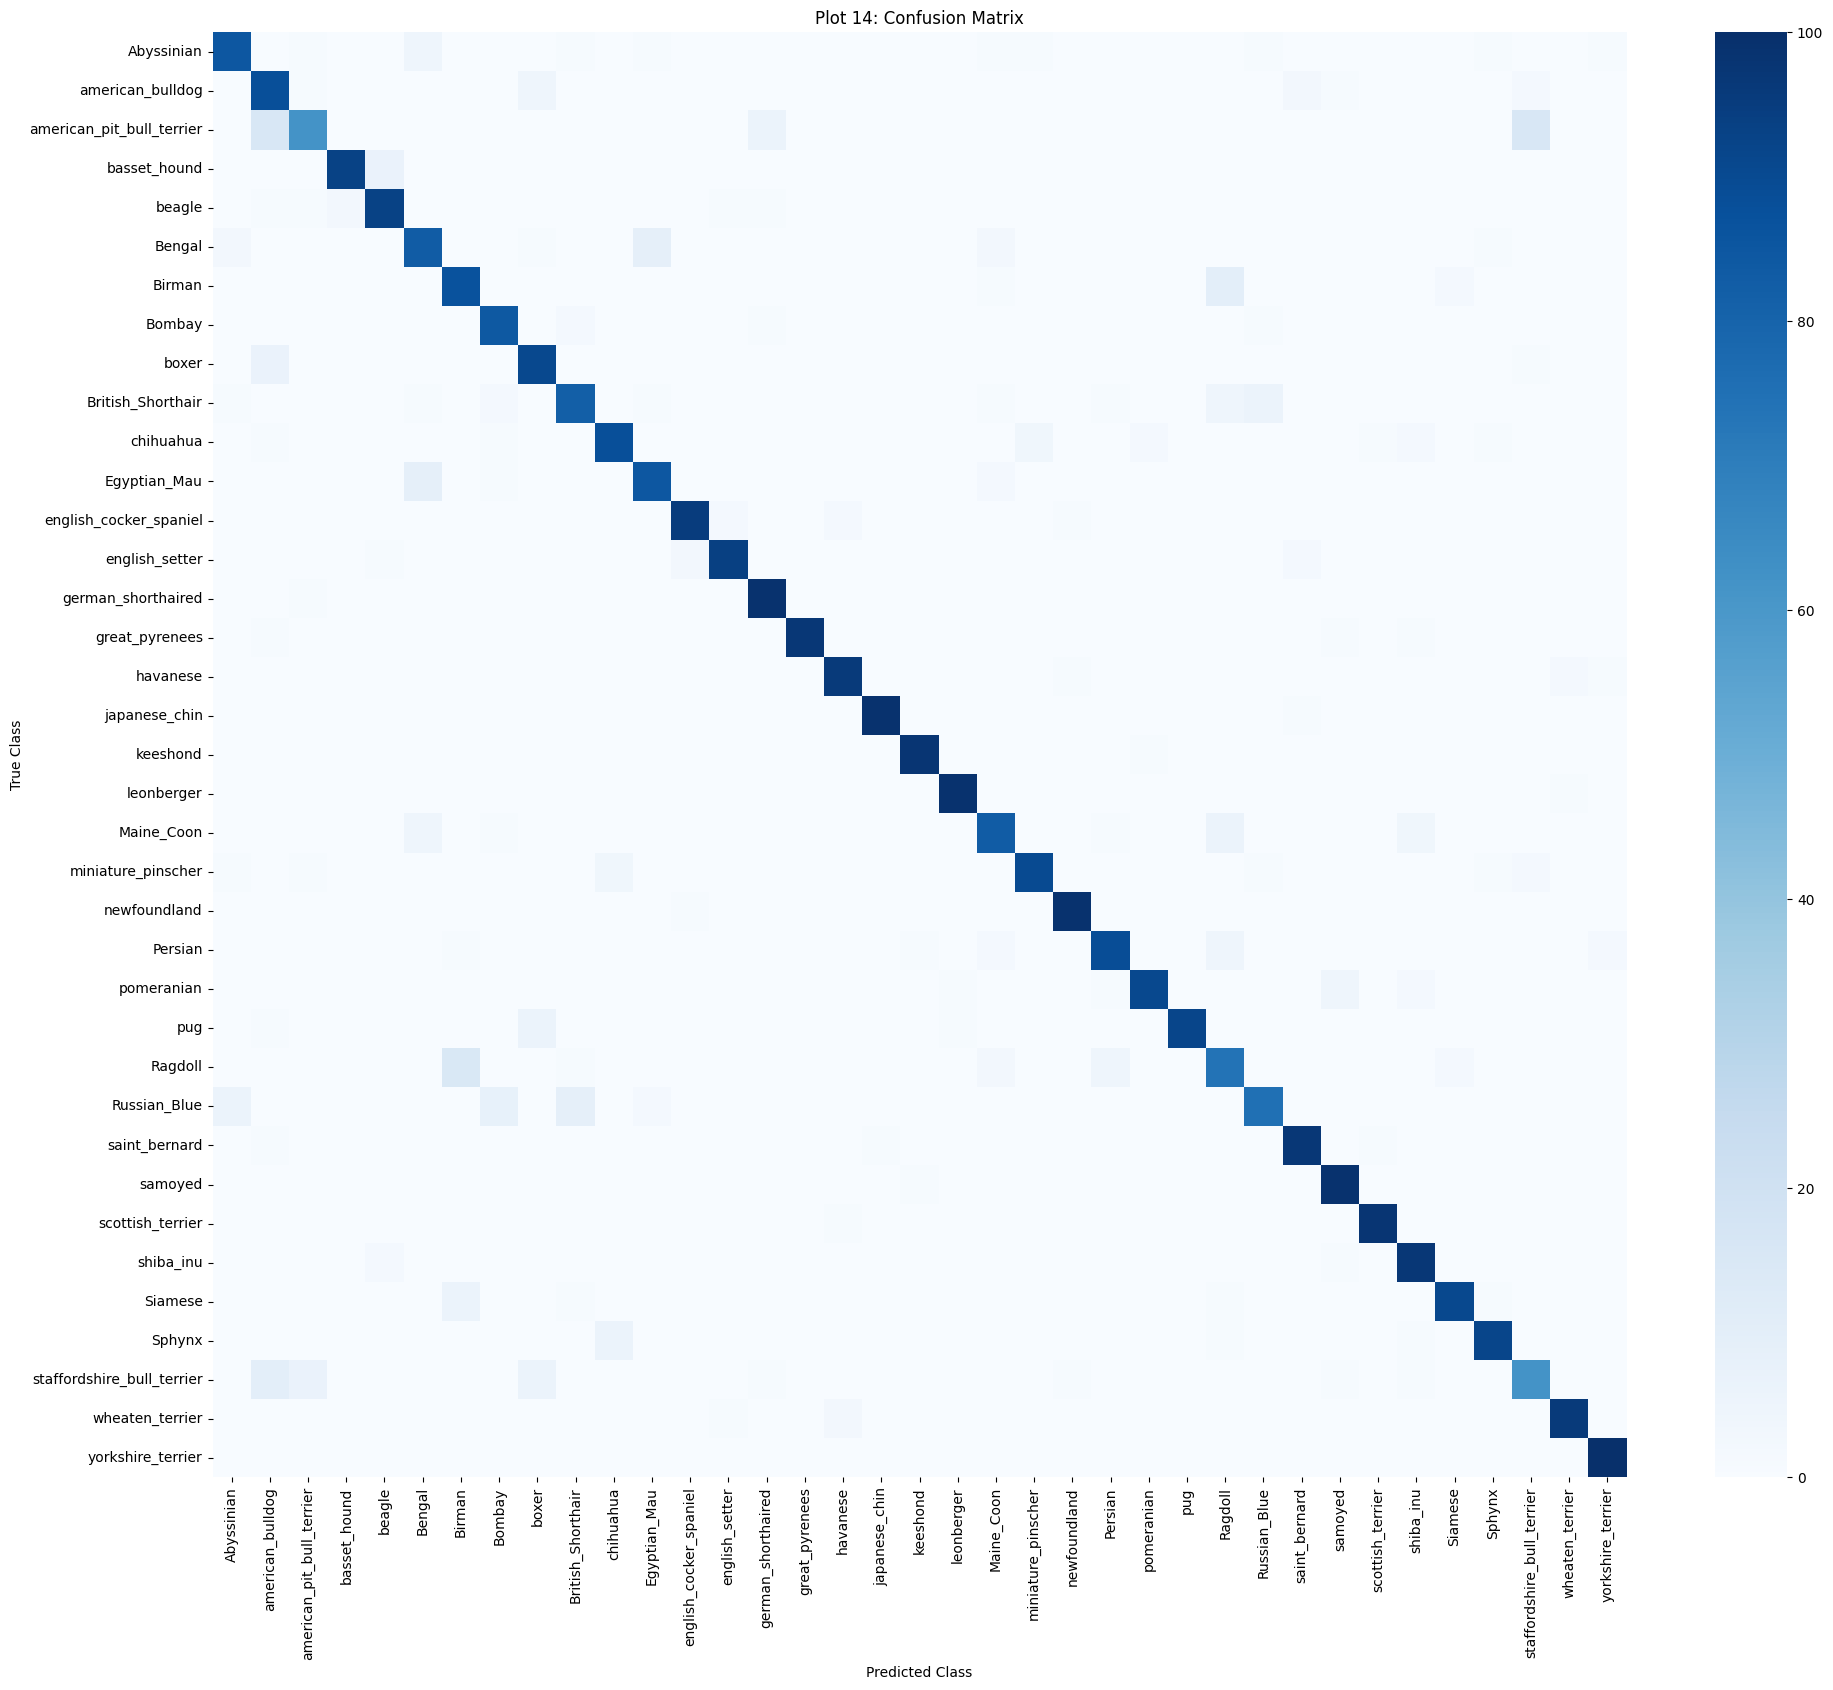


BEST CLASSIFIED CLASSES
yorkshire_terrier - 100.00%
newfoundland - 99.00%
leonberger - 99.00%
japanese_chin - 99.00%
samoyed - 99.00%

MOST FREQUENTLY CONFUSED CLASSES
american_pit_bull_terrier → staffordshire_bull_terrier : 16 images
american_pit_bull_terrier → american_bulldog : 16 images
Ragdoll → Birman : 15 images
staffordshire_bull_terrier → american_bulldog : 10 images
Birman → Ragdoll : 10 images
Russian_Blue → British_Shorthair : 9 images
Egyptian_Mau → Bengal : 9 images
Bengal → Egyptian_Mau : 9 images
Russian_Blue → Bombay : 8 images
staffordshire_bull_terrier → american_pit_bull_terrier : 7 images

MISCLASSIFIED IMAGES
Total Misclassified Images: 346


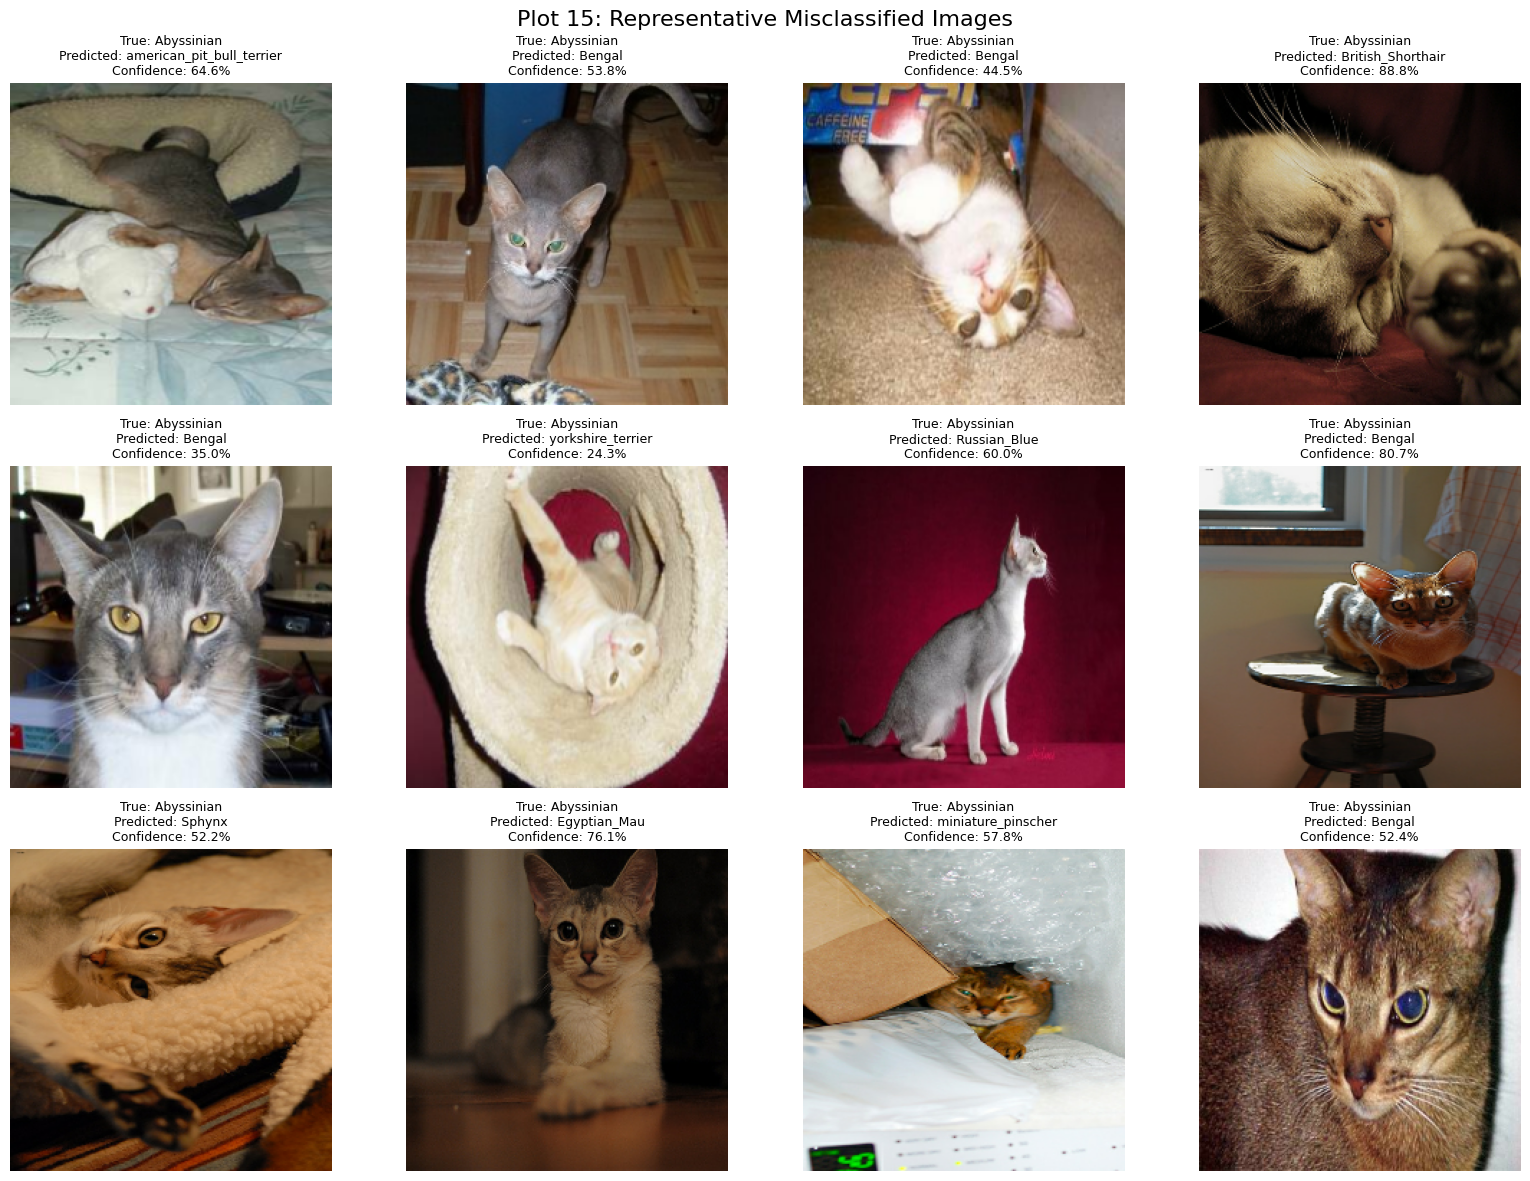


EXPERIMENT COMPLETED SUCCESSFULLY

Best Configuration: C1
Mean CV Accuracy: 90.30%
CV Standard Deviation: 1.30%
Independent Test Accuracy: 90.57%
Weighted Precision: 90.74%
Weighted Recall: 90.57%
Weighted F1-score: 90.52%
Training Time: 1.69 minutes
Number of Parameters: 2,305,381

Final model saved as:
final_mobilenetv2_oxford_pet.keras


In [ ]:
# ============================================================
# 12. FINAL MODEL RETRAINING AND TEST EVALUATION
# ============================================================
#
# Steps:
# 1. Select the best configuration from 5-Fold CV
# 2. Retrain using complete training + validation data
# 3. Keep test set untouched during training
# 4. Evaluate the final model on the independent test set
#
# Outputs:
# - Mean CV Accuracy
# - CV Standard Deviation
# - Test Accuracy
# - Precision
# - Recall
# - F1-score
# - Training Time
# - Number of Parameters
# - Plot 14: Confusion Matrix
# - Plot 15: Misclassified Images
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
import gc

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ------------------------------------------------------------
# 2. SELECT THE BEST CONFIGURATION
# ------------------------------------------------------------
#
# Primary criterion:
# Highest Mean Cross-Validation Accuracy
#
# If two configurations have the same mean accuracy,
# the one with lower Standard Deviation is preferred.
# ------------------------------------------------------------

best_config_name = sorted(
    all_results.keys(),

    key=lambda x: (
        -all_results[x]["Mean Accuracy"],
        all_results[x]["Standard Deviation"]
    )

)[0]


best_config = configurations[
    best_config_name
]


best_cv_accuracy = all_results[
    best_config_name
]["Mean Accuracy"]


best_cv_std = all_results[
    best_config_name
]["Standard Deviation"]


print("=" * 80)
print("BEST CONFIGURATION SELECTED FROM CROSS-VALIDATION")
print("=" * 80)

print("\nConfiguration:", best_config_name)

print(
    "Learning Rate:",
    best_config["learning_rate"]
)

print(
    "Batch Size:",
    best_config["batch_size"]
)

print(
    "Dropout Rate:",
    best_config["dropout_rate"]
)

print(
    "Optimizer:",
    best_config["optimizer"]
)

print(
    "\nMean CV Accuracy:",
    round(best_cv_accuracy, 2),
    "%"
)

print(
    "CV Standard Deviation:",
    round(best_cv_std, 2),
    "%"
)

print(
    "CV Result:",
    f"{best_cv_accuracy:.2f} ± {best_cv_std:.2f}%"
)

print("=" * 80)


# ------------------------------------------------------------
# 3. CREATE COMPLETE TRAINING DATASET
# ------------------------------------------------------------
#
# IMPORTANT:
#
# train_paths + val_paths are combined for final training.
#
# test_paths are NOT included here.
# ------------------------------------------------------------

complete_train_paths = np.concatenate([
    np.array(train_paths),
    np.array(val_paths)
])


complete_train_labels = np.concatenate([
    np.array(train_labels),
    np.array(val_labels)
])


print("\nCOMPLETE TRAINING DATA")

print(
    "Training Samples:",
    len(train_paths)
)

print(
    "Validation Samples:",
    len(val_paths)
)

print(
    "Complete Training Samples:",
    len(complete_train_paths)
)

print(
    "Test Samples:",
    len(test_paths)
)

print(
    "\nThe test set has NOT been used for training."
)


# ------------------------------------------------------------
# 4. IMAGE PREPROCESSING FUNCTION
# ------------------------------------------------------------

def preprocess_image(image_path, label):

    # Read image
    image = tf.io.read_file(
        image_path
    )

    # Decode as RGB
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Convert to float
    image = tf.cast(
        image,
        tf.float32
    )

    # Resize
    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    # MobileNetV2 normalization
    image = tf.keras.applications.mobilenet_v2.preprocess_input(
        image
    )

    return image, label


# ------------------------------------------------------------
# 5. CREATE DATASET FUNCTION
# ------------------------------------------------------------

def create_dataset(
    image_paths,
    labels,
    batch_size,
    training=False
):

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            image_paths,
            labels
        )
    )


    # Shuffle only training data
    if training:

        dataset = dataset.shuffle(
            buffer_size=len(image_paths),
            seed=42,
            reshuffle_each_iteration=True
        )


    # Preprocess images
    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )


    # Batch
    dataset = dataset.batch(
        batch_size
    )


    # Prefetch
    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )


    return dataset


# ------------------------------------------------------------
# 6. CREATE OPTIMIZER FUNCTION
# ------------------------------------------------------------

def get_optimizer(
    optimizer_name,
    learning_rate
):

    if optimizer_name == "SGD":

        return keras.optimizers.SGD(
            learning_rate=learning_rate
        )


    elif optimizer_name == "Momentum":

        return keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )


    elif optimizer_name == "RMSProp":

        return keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )


    else:

        return keras.optimizers.Adam(
            learning_rate=learning_rate
        )


# ------------------------------------------------------------
# 7. CREATE FINAL MODEL
# ------------------------------------------------------------

def create_final_model(
    learning_rate,
    dropout_rate,
    optimizer_name
):

    # Load pretrained MobileNetV2
    base_model = keras.applications.MobileNetV2(

        input_shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        ),

        include_top=False,

        weights="imagenet"
    )


    # Feature extraction
    base_model.trainable = False


    # Input
    inputs = keras.Input(
        shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        )
    )


    # MobileNetV2 feature extraction
    x = base_model(
        inputs,
        training=False
    )


    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(
        x
    )


    # Dropout
    if dropout_rate > 0:

        x = layers.Dropout(
            dropout_rate
        )(x)


    # Final classification layer
    outputs = layers.Dense(

        NUM_CLASSES,

        activation="softmax",

        name="classifier"

    )(x)


    # Create model
    model = keras.Model(
        inputs=inputs,
        outputs=outputs
    )


    # Get selected optimizer
    optimizer = get_optimizer(
        optimizer_name,
        learning_rate
    )


    # Compile
    model.compile(

        optimizer=optimizer,

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )


    return model


# ------------------------------------------------------------
# 8. CREATE FINAL TRAINING DATASET
# ------------------------------------------------------------

FINAL_BATCH_SIZE = best_config[
    "batch_size"
]


complete_train_ds = create_dataset(

    complete_train_paths,

    complete_train_labels,

    batch_size=FINAL_BATCH_SIZE,

    training=True
)


# ------------------------------------------------------------
# 9. CREATE INDEPENDENT TEST DATASET
# ------------------------------------------------------------

test_ds = create_dataset(

    test_paths,

    test_labels,

    batch_size=FINAL_BATCH_SIZE,

    training=False
)


# ------------------------------------------------------------
# 10. CREATE FINAL MODEL
# ------------------------------------------------------------

keras.backend.clear_session()

gc.collect()

keras.utils.set_random_seed(
    42
)


final_model = create_final_model(

    learning_rate=best_config[
        "learning_rate"
    ],

    dropout_rate=best_config[
        "dropout_rate"
    ],

    optimizer_name=best_config[
        "optimizer"
    ]
)


# ------------------------------------------------------------
# 11. MODEL INFORMATION
# ------------------------------------------------------------

number_of_parameters = final_model.count_params()


print("\n" + "=" * 80)
print("FINAL MODEL INFORMATION")
print("=" * 80)

print(
    "Number of Parameters:",
    f"{number_of_parameters:,}"
)


# ------------------------------------------------------------
# 12. RETRAIN FINAL MODEL
# ------------------------------------------------------------
#
# Test data is NOT used during this stage.
# ------------------------------------------------------------

FINAL_EPOCHS = 10


print("\n" + "=" * 80)
print("FINAL MODEL TRAINING")
print("=" * 80)

print(
    "Training on complete training data..."
)

print(
    "Test set remains untouched."
)


# Start timer
training_start_time = time.time()


# Train model
final_history = final_model.fit(

    complete_train_ds,

    epochs=FINAL_EPOCHS,

    verbose=1
)


# End timer
training_end_time = time.time()


# Calculate training time
training_time_seconds = (

    training_end_time
    -
    training_start_time

)


training_time_minutes = (

    training_time_seconds
    /
    60

)


# ------------------------------------------------------------
# 13. EVALUATE ON INDEPENDENT TEST SET
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL INDEPENDENT TEST EVALUATION")
print("=" * 80)

print(
    "The test set is being used for the first time."
)


test_loss, test_accuracy = final_model.evaluate(

    test_ds,

    verbose=1
)


test_accuracy_percent = (
    test_accuracy
    *
    100
)


# ------------------------------------------------------------
# 14. GET TEST PREDICTIONS
# ------------------------------------------------------------

print(
    "\nGenerating predictions..."
)


predicted_probabilities = final_model.predict(

    test_ds,

    verbose=1
)


# Predicted classes
y_pred = np.argmax(

    predicted_probabilities,

    axis=1
)


# True labels
y_true = np.array(
    test_labels
)


# ------------------------------------------------------------
# 15. CALCULATE PERFORMANCE METRICS
# ------------------------------------------------------------

precision = precision_score(

    y_true,

    y_pred,

    average="weighted",

    zero_division=0

)


recall = recall_score(

    y_true,

    y_pred,

    average="weighted",

    zero_division=0

)


f1 = f1_score(

    y_true,

    y_pred,

    average="weighted",

    zero_division=0

)


# ------------------------------------------------------------
# 16. FINAL RESULTS TABLE
# ------------------------------------------------------------

final_results = {

    "Metric": [

        "Mean CV Accuracy",

        "CV Standard Deviation",

        "Test Accuracy",

        "Precision",

        "Recall",

        "F1-score",

        "Training Time",

        "Number of Parameters"

    ],

    "Value": [

        f"{best_cv_accuracy:.2f}%",

        f"{best_cv_std:.2f}%",

        f"{test_accuracy_percent:.2f}%",

        f"{precision * 100:.2f}%",

        f"{recall * 100:.2f}%",

        f"{f1 * 100:.2f}%",

        f"{training_time_seconds:.2f} seconds ({training_time_minutes:.2f} minutes)",

        f"{number_of_parameters:,}"

    ]

}


results_table = pd.DataFrame(
    final_results
)


print("\n" + "=" * 80)
print("FINAL MODEL PERFORMANCE")
print("=" * 80)


display(
    results_table
)


# ------------------------------------------------------------
# 17. DETAILED CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)


# Use class_names if available
if "class_names" in globals():

    target_names = class_names

else:

    target_names = [

        f"Class {i}"

        for i in range(
            NUM_CLASSES
        )

    ]


print(

    classification_report(

        y_true,

        y_pred,

        labels=list(
            range(NUM_CLASSES)
        ),

        target_names=target_names,

        zero_division=0

    )

)


# ============================================================
# 18. PLOT 14: CONFUSION MATRIX
# ============================================================

print("\nGenerating Plot 14: Confusion Matrix...")


conf_matrix = confusion_matrix(

    y_true,

    y_pred,

    labels=list(
        range(NUM_CLASSES)
    )

)


plt.figure(
    figsize=(20, 17)
)


sns.heatmap(

    conf_matrix,

    cmap="Blues",

    xticklabels=target_names,

    yticklabels=target_names,

    cbar=True

)


plt.title(
    "Plot 14: Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.xticks(
    rotation=90
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 19. BEST CLASSIFIED CLASSES
# ------------------------------------------------------------
#
# Calculate per-class accuracy.
# ------------------------------------------------------------

class_accuracies = []


for class_index in range(
    NUM_CLASSES
):

    class_mask = (
        y_true == class_index
    )


    total_class_samples = np.sum(
        class_mask
    )


    if total_class_samples > 0:

        correct_predictions = np.sum(

            y_pred[class_mask]
            ==
            y_true[class_mask]

        )


        class_accuracy = (

            correct_predictions
            /
            total_class_samples

        )


    else:

        class_accuracy = 0


    class_accuracies.append(
        class_accuracy
    )


best_class_indices = np.argsort(

    class_accuracies

)[-5:][::-1]


print("\n" + "=" * 80)
print("BEST CLASSIFIED CLASSES")
print("=" * 80)


for class_index in best_class_indices:

    print(

        target_names[class_index],

        "-",

        f"{class_accuracies[class_index] * 100:.2f}%"

    )


# ------------------------------------------------------------
# 20. MOST FREQUENTLY CONFUSED CLASSES
# ------------------------------------------------------------

confusion_pairs = []


for true_class in range(
    NUM_CLASSES
):

    for predicted_class in range(
        NUM_CLASSES
    ):

        # Ignore correct predictions
        if true_class != predicted_class:

            confusion_count = conf_matrix[
                true_class,
                predicted_class
            ]


            if confusion_count > 0:

                confusion_pairs.append(

                    (

                        confusion_count,

                        true_class,

                        predicted_class

                    )

                )


# Sort from highest confusion
confusion_pairs.sort(
    reverse=True
)


print("\n" + "=" * 80)
print("MOST FREQUENTLY CONFUSED CLASSES")
print("=" * 80)


for count, true_class, predicted_class in confusion_pairs[:10]:

    print(

        f"{target_names[true_class]}"

        f" → "

        f"{target_names[predicted_class]}"

        f" : "

        f"{count} images"

    )


# ============================================================
# 21. PLOT 15: MISCLASSIFIED IMAGES
# ============================================================

misclassified_indices = np.where(

    y_true != y_pred

)[0]


print("\n" + "=" * 80)
print("MISCLASSIFIED IMAGES")
print("=" * 80)

print(
    "Total Misclassified Images:",
    len(misclassified_indices)
)


# Number of representative examples
NUM_IMAGES_TO_DISPLAY = min(
    12,
    len(misclassified_indices)
)


if NUM_IMAGES_TO_DISPLAY > 0:

    selected_indices = misclassified_indices[
        :NUM_IMAGES_TO_DISPLAY
    ]


    plt.figure(
        figsize=(16, 12)
    )


    for plot_index, image_index in enumerate(
        selected_indices
    ):


        # Load original image
        image = tf.io.read_file(
            test_paths[image_index]
        )


        image = tf.image.decode_jpeg(

            image,

            channels=3

        )


        image = tf.image.resize(

            image,

            (224, 224)

        )


        # Create subplot
        plt.subplot(
            3,
            4,
            plot_index + 1
        )


        plt.imshow(
            image.numpy().astype("uint8")
        )


        true_label = target_names[
            y_true[image_index]
        ]


        predicted_label = target_names[
            y_pred[image_index]
        ]


        confidence = (

            np.max(
                predicted_probabilities[
                    image_index
                ]
            )

            * 100

        )


        plt.title(

            f"True: {true_label}\n"

            f"Predicted: {predicted_label}\n"

            f"Confidence: {confidence:.1f}%",

            fontsize=9

        )


        plt.axis(
            "off"
        )


    plt.suptitle(

        "Plot 15: Representative Misclassified Images",

        fontsize=16

    )


    plt.tight_layout()

    plt.show()


else:

    print(
        "No misclassified images found."
    )


# ============================================================
# 22. SAVE FINAL MODEL
# ============================================================

final_model.save(
    "final_mobilenetv2_oxford_pet.keras"
)


print("\n" + "=" * 80)
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print("=" * 80)

print(
    "\nBest Configuration:",
    best_config_name
)

print(
    "Mean CV Accuracy:",
    f"{best_cv_accuracy:.2f}%"
)

print(
    "CV Standard Deviation:",
    f"{best_cv_std:.2f}%"
)

print(
    "Independent Test Accuracy:",
    f"{test_accuracy_percent:.2f}%"
)

print(
    "Weighted Precision:",
    f"{precision * 100:.2f}%"
)

print(
    "Weighted Recall:",
    f"{recall * 100:.2f}%"
)

print(
    "Weighted F1-score:",
    f"{f1 * 100:.2f}%"
)

print(
    "Training Time:",
    f"{training_time_minutes:.2f} minutes"
)

print(
    "Number of Parameters:",
    f"{number_of_parameters:,}"
)

print(
    "\nFinal model saved as:"
)

print(
    "final_mobilenetv2_oxford_pet.keras"
)

print("=" * 80)